# Intro

In this notebook, the idea was to, first prepare the data, by cleaning it, and feed it to some models for training, and after that, analyse the prediction and find why the model is predicting the way it is. I was also thinking, if the model perform well or not, to explain why it does and if he uses the right features (like alpha subband signal). 

So, I tried to: 

Clean the eeg data: 

- I apply a notch filter to remove powerline interference, which is a common source of noise in EEG signals. I explain why below
- I filter the signal to be between .5 and 32hz because the brainwave frequencies of interest are typically within this range
- I also tried to remove baseline, re-reference the signals, and remove correlated electrodes. I explain why I do this below. I don't think the result is super, so I finally skip those steps.

Train the models:
- I tried Logistic Regression, Explainable Boosting Machine (EBM), and XGBoost models with the electrode signals and subband signals as input features. I found different results for each model. They perform not so well, and I tried to plot feature importance to see if the model uses the right features. I didn't already well analyse the results.
- I'm planning to train with torch.eeg models, one using CNN and the other using LSTM, and compare the results with the models above. I didn't do this yet because I want finally to integrate MLflow to track all experiments and compare the results.
- I tried to train XGBoost with shuffle data to see if how the model performs with shuffled data. The idea is to compare to the result obtain and share by Alaa. 

What's next:
- Integrate MLflow to track all experiments to compare the results.
- Redo the cleaning steps with MNE.
- Train the models with torch.eeg models, one using CNN and the other using LSTM, and compare the results with other implemented models.
- Use explainability techniques like SHAP to explain the model predictions.

What's I found interesting (apart from the results):
- Torch.eeg already has some feature engineering steps implemented, like the subband signals extraction. I think that what left is to prepare the data by removing noise/artifacts. 
- And MNE has some implemented functions to remove noise/artifacts. I think it's interesting to use it to clean the data.

### EEG signals cleaning 

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

eeg_df = pd.read_csv('../data/EyeStateData.csv')
eeg_df.head()

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,EyeDetection
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,0
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,0
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,0
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,0
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,0


In [66]:
electrodes = eeg_df.columns[:-1]
eeg_df.rename(columns={'EyeDetection': 'target'}, inplace=True)
eeg_df['label'] = eeg_df['target'].map({0: 'closed', 1: 'open'})
fs = 128

#### Apply notch filter

 In EEG recordings, AC noise (often around 50 or 60 Hz, depending on the region) comes from electrical systems and appliances in the environment. This noise can interfere with the EEG signals by adding unwanted frequencies that overlap with brainwave frequencies, making it challenging to isolate neural activity.
 
A notch filter, or band-stop filter, targets a very narrow frequency range and attenuates it, often a specific frequency (like 50 or 60 Hz). This is useful for filtering out powerline interference, which is a common source of noise in biological signals. 

In [5]:
from scipy.signal import butter, lfilter

def butter_bandstop_filter(data, lowcut, highcut, fs, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='bandstop')
    y = lfilter(b, a, data)
    return y

def notch_filter(data, fs):
    return butter_bandstop_filter(data, 49, 51, fs)

notch_filter_filtered_df = eeg_df[electrodes].apply(lambda x: notch_filter(x, fs), axis=0)

Text(0, 0.5, 'Amplitude')

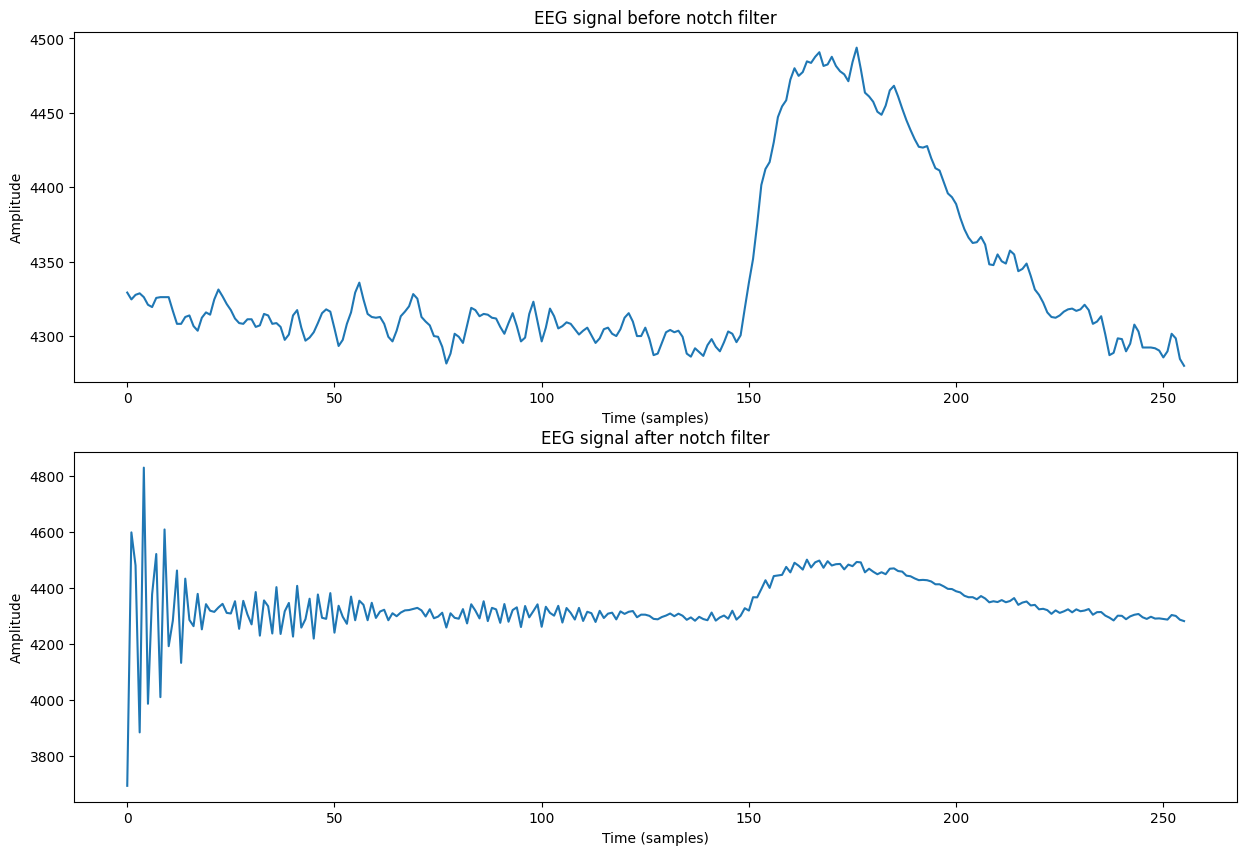

In [6]:
# plot the EEG signal before and after applying the notch filter

fig, axs = plt.subplots(2, 1, figsize=(15, 10))
axs[0].plot(eeg_df['AF3'][:fs*2])
axs[0].set_title('EEG signal before notch filter')
axs[0].set_xlabel('Time (samples)')
axs[0].set_ylabel('Amplitude')
axs[1].plot(notch_filter_filtered_df['AF3'][:fs*2])
axs[1].set_title('EEG signal after notch filter')
axs[1].set_xlabel('Time (samples)')
axs[1].set_ylabel('Amplitude')

#### Apply bandpass filter

The bandpass filter is used to filter out unwanted noise from the EEG signal. The bandpass filter allows only the frequencies within a certain range to pass through, while blocking all other frequencies. This is useful for isolating the brainwave frequencies of interest and removing any noise that may be present in the signal.

In [54]:
from scipy.signal import butter, lfilter

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    y = lfilter(b, a, data)
    return y

def bandpass_filter(data, fs):
    return butter_bandpass_filter(data, .5, 32, fs)

bandpass_filtered_df = notch_filter_filtered_df[electrodes].apply(lambda x: bandpass_filter(x, fs), axis=0)

Text(0, 0.5, 'Amplitude')

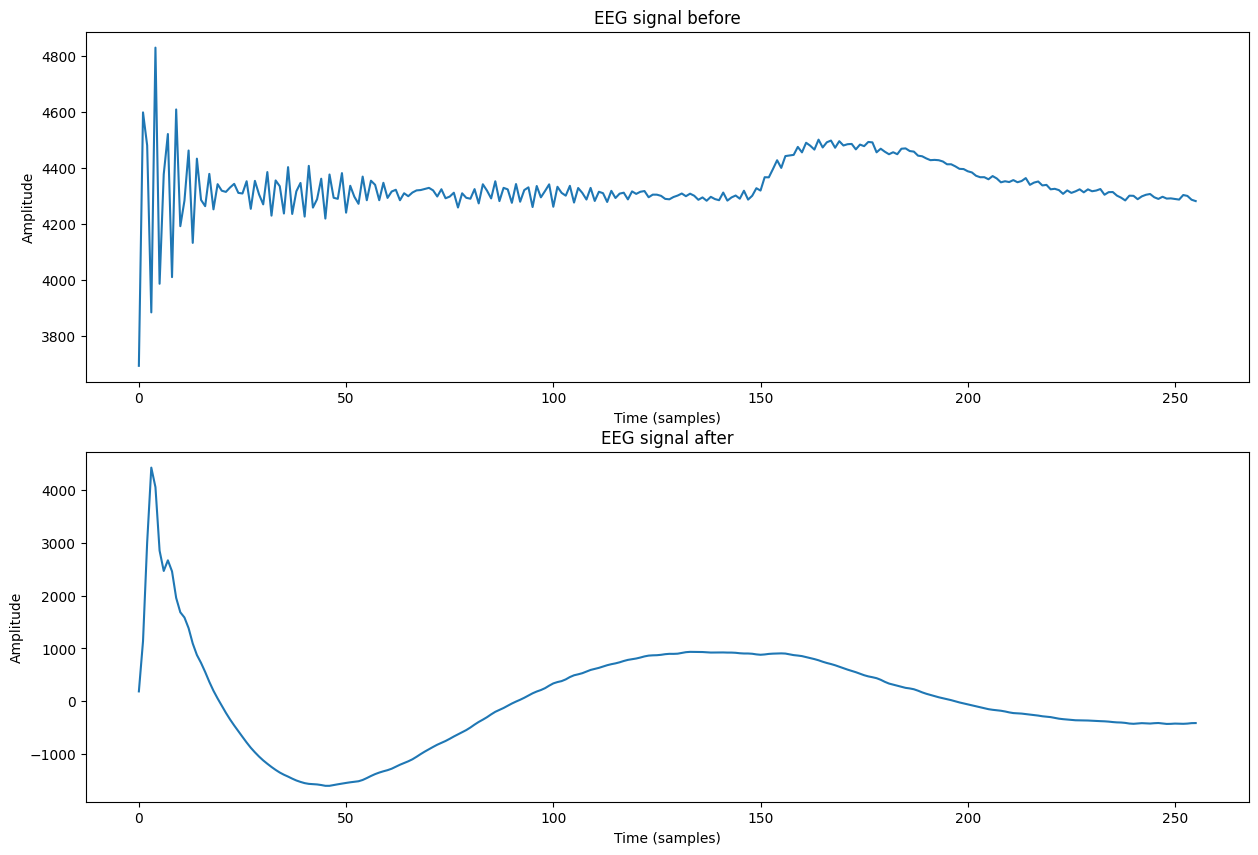

In [55]:
# plot the EEG signal before and after applying the notch filter

fig, axs = plt.subplots(2, 1, figsize=(15, 10))
axs[0].plot(notch_filter_filtered_df['AF3'][:fs*2])
axs[0].set_title('EEG signal before')
axs[0].set_xlabel('Time (samples)')
axs[0].set_ylabel('Amplitude')
axs[1].plot(bandpass_filtered_df['AF3'][:fs*2])
axs[1].set_title('EEG signal after')
axs[1].set_xlabel('Time (samples)')
axs[1].set_ylabel('Amplitude')

#### Remove baseline

The baseline is the average amplitude of the EEG signal over a certain period of time. It is often used as a reference point for comparing the amplitude of the signal at different time points. Removing the baseline can help to highlight changes in the EEG signal that are not related to the overall level of activity in the brain.


In [10]:
def remove_baseline(data):
    return data - np.mean(data, axis=0)

baseline_df = bandpass_filtered_df[electrodes].apply(remove_baseline)

Text(0, 0.5, 'Amplitude')

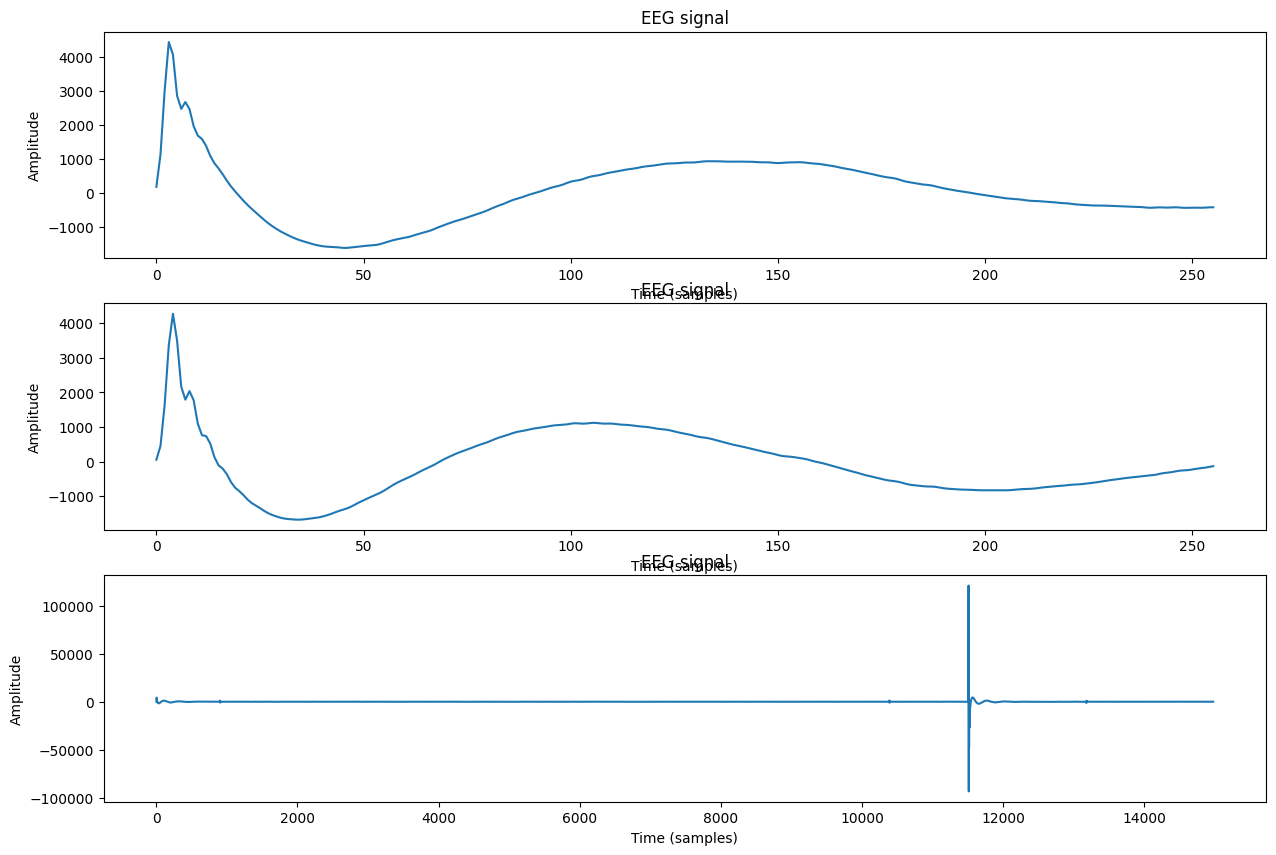

In [63]:
# plot the EEG signal before and after removing the baseline

fig, axs = plt.subplots(3, 1, figsize=(15, 10))
axs[0].plot(bandpass_filtered_df['AF3'][:fs*2])
axs[0].set_title('EEG signal')
axs[0].set_xlabel('Time (samples)')
axs[0].set_ylabel('Amplitude')
axs[1].plot(baseline_df['AF3'][:fs*2])
axs[1].set_title('EEG signal')
axs[1].set_xlabel('Time (samples)')
axs[1].set_ylabel('Amplitude')
axs[2].plot(baseline_df['AF3'])
axs[2].set_title('EEG signal')
axs[2].set_xlabel('Time (samples)')
axs[2].set_ylabel('Amplitude')

#### Re-reference the signals

Re-referencing is the process of changing the reference electrode for the EEG signal. This can help to reduce noise and improve the quality of the signal. Common re-referencing methods include the average reference and the common average reference. The average reference subtracts the average signal from all electrodes from each electrode signal, while the common average reference subtracts the average signal from all but one electrode from each electrode signal. We will use the common average reference method in this notebook.


In [13]:
def re_reference(data):
    mean_signal = np.mean(data, axis=1)
    return data.subtract(mean_signal, axis=0)

re_referenced_df = re_reference(baseline_df)

Text(0, 0.5, 'Amplitude')

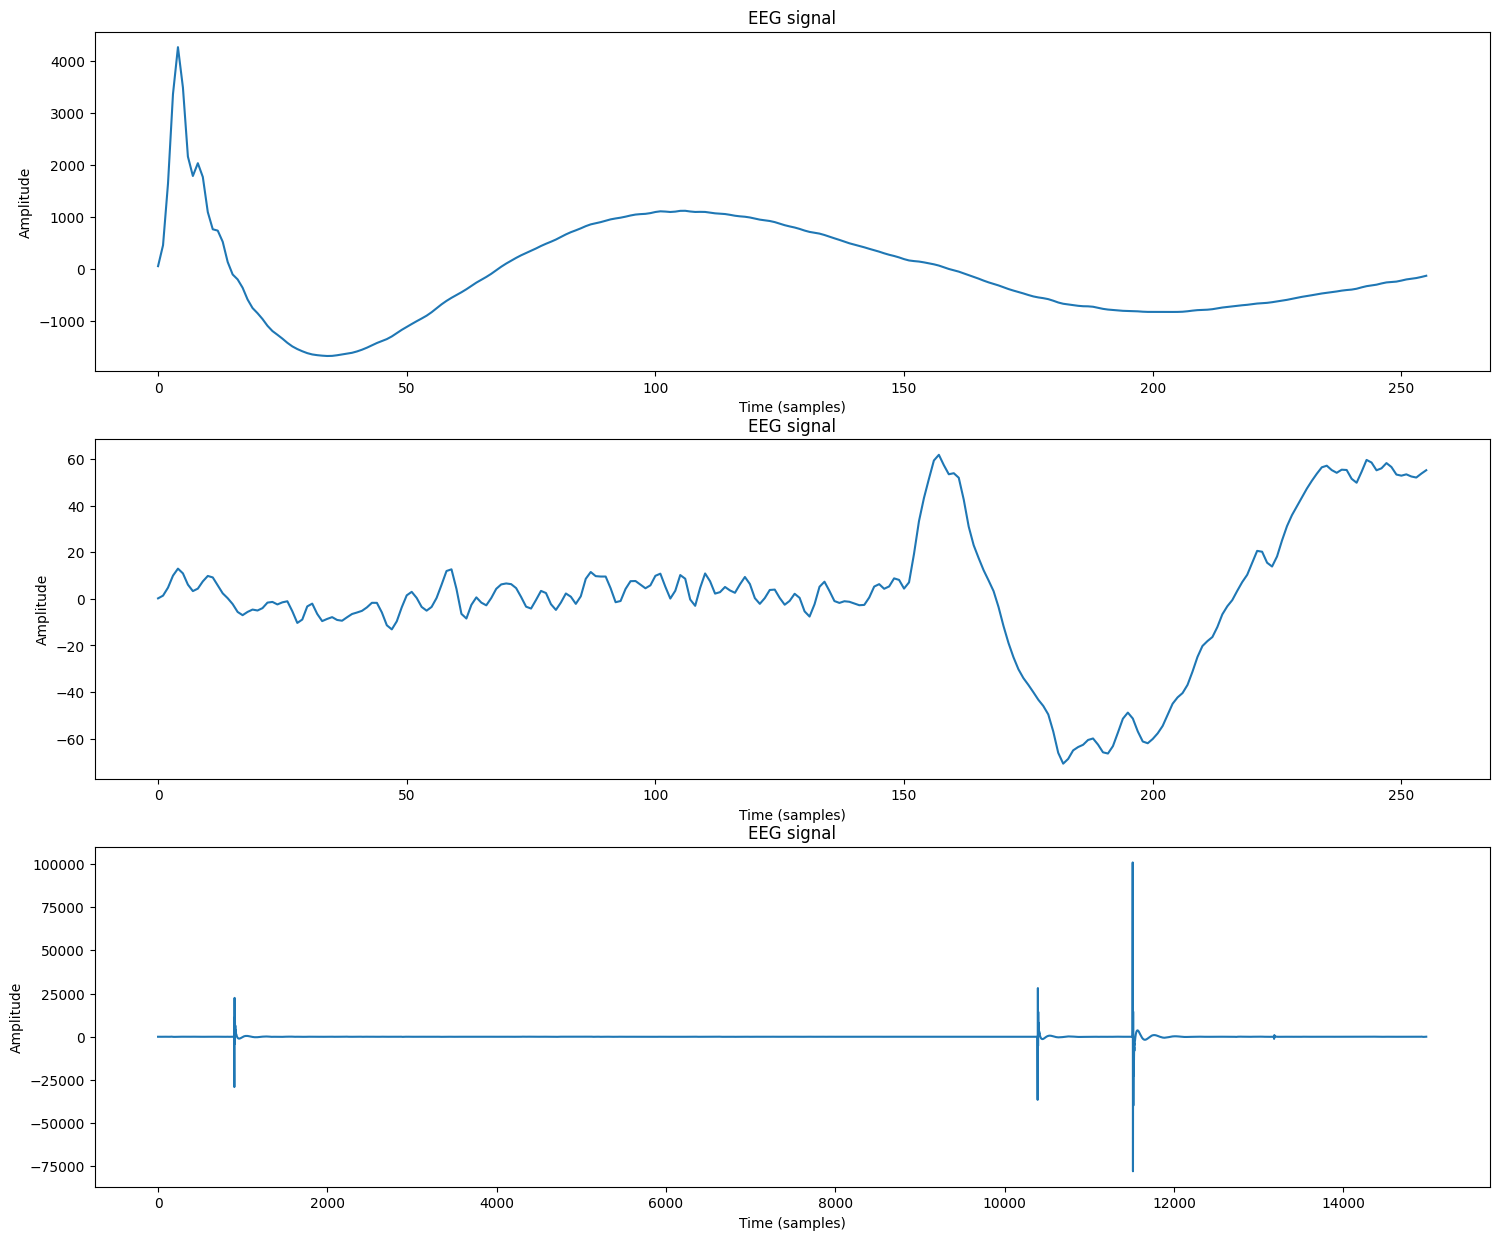

In [64]:
# plot the EEG signal before and after removing the baseline

fig, axs = plt.subplots(3, 1, figsize=(18, 15))
axs[0].plot(baseline_df['AF3'][:fs*2])
axs[0].set_title('EEG signal')
axs[0].set_xlabel('Time (samples)')
axs[0].set_ylabel('Amplitude')
axs[1].plot(re_referenced_df['AF3'][:fs*2])
axs[1].set_title('EEG signal')
axs[1].set_xlabel('Time (samples)')
axs[1].set_ylabel('Amplitude')
axs[2].plot(re_referenced_df['AF3'])
axs[2].set_title('EEG signal')
axs[2].set_xlabel('Time (samples)')
axs[2].set_ylabel('Amplitude')

#### Remove correlated electrode

Correlated electrodes are electrodes that have a high degree of similarity in their signals. This can be due to a number of factors, such as the physical proximity of the electrodes or the fact that they are measuring the same underlying neural activity. Removing correlated electrodes can help to reduce redundancy in the data and improve the quality of the signal.

Correlated electrodes: ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']


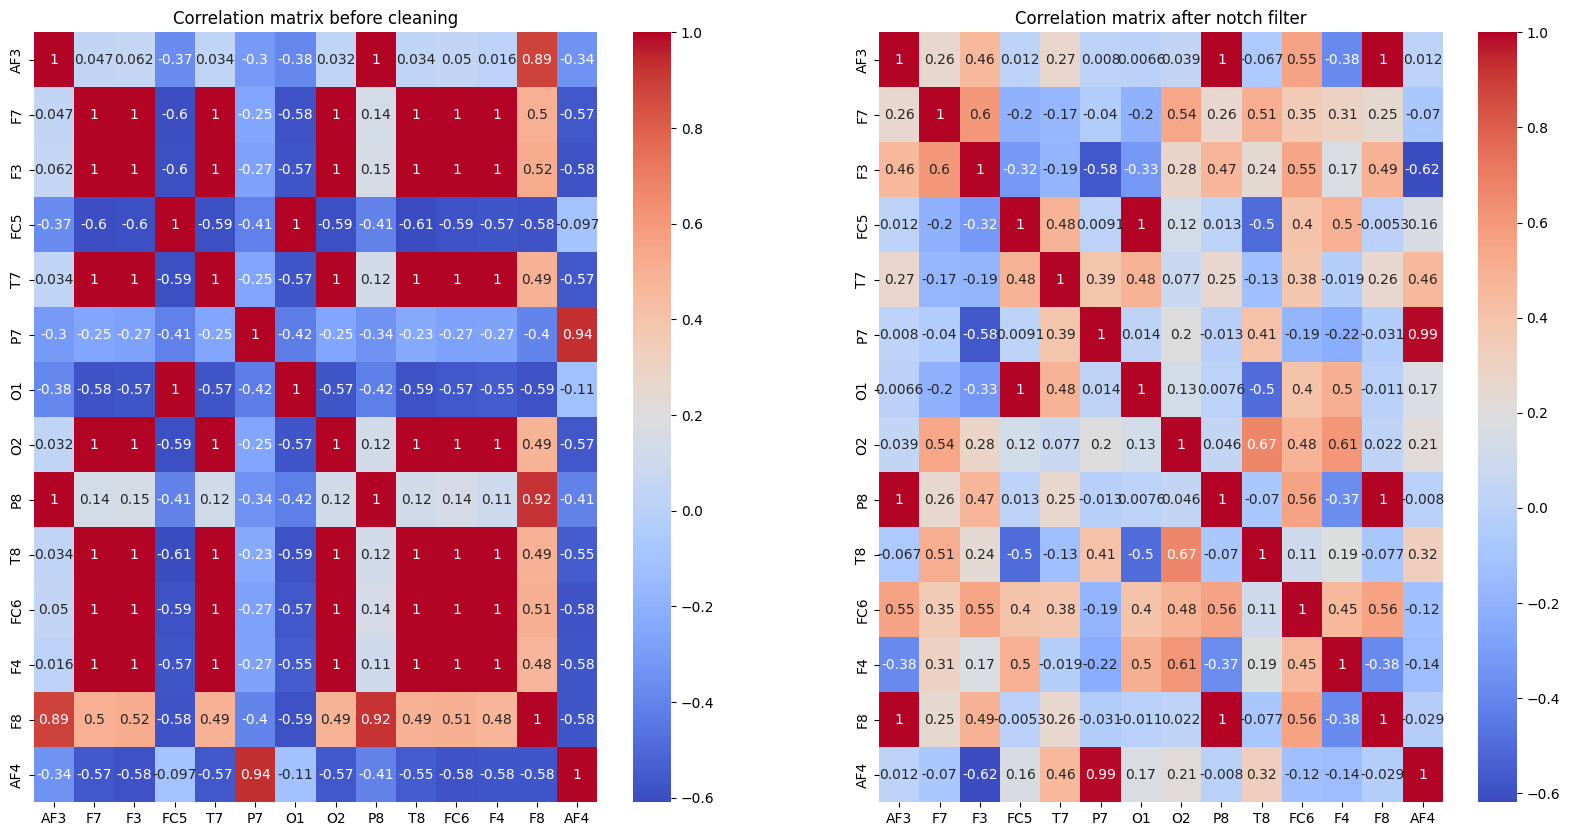

In [60]:
def remove_correlated_electrodes(data):
    corr_matrix = data.corr()
    corr_matrix = np.abs(corr_matrix)
    np.fill_diagonal(corr_matrix.values, 0)
    # print(corr_matrix.columns, corr_matrix)
    correlated_electrodes = [col for col in corr_matrix.columns if any(corr_matrix[col] > 0.8)]
    return data.drop(columns=correlated_electrodes), correlated_electrodes

cleaned_df, correlated_electrodes = remove_correlated_electrodes(re_referenced_df)

print(f'Correlated electrodes: {correlated_electrodes}')

# plot the correlation matrix
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
sns.heatmap(re_referenced_df.corr(), annot=True, cmap='coolwarm', ax=ax[0])
ax[0].set_title('Correlation matrix before cleaning')
# ax[1].imshow(cleaned_df.corr(), cmap='coolwarm', interpolation='none')
# ax[1].set_title('Correlation matrix after cleaning')
sns.heatmap(notch_filter_filtered_df.corr(), annot=True, cmap='coolwarm', ax=ax[1])
ax[1].set_title('Correlation matrix after notch filter')
plt.show()

When I remove the baseline and re-reference the signals, I can see that the correlation between the electrodes increases. This is because the baseline removal and re-referencing process can introduce common components to the signals, which can increase the correlation between them. I choose to skip those step for now, since there are no electrode signal after removing the correlated electrodes. 

More deep explanation from ChatGPT:

When you remove the baseline from each electrode's signal, it can lead to increased correlation among the signals for several reasons:

1. **Shared Artifacts**: EEG recordings often contain common artifacts (e.g., eye blinks, muscle movements) that affect multiple channels simultaneously. Removing the baseline does not eliminate these artifacts; instead, it may accentuate their effects, causing the signals to become more similar and, hence, correlated.

2. **Common Neural Activity**: EEG signals reflect the combined electrical activity of neurons in the brain. When you remove the baseline, the remaining signal primarily represents the variations in brain activity. If different electrodes are detecting the same underlying neural activity, their signals will become more correlated.

3. **Drift Removal**: Baseline removal eliminates low-frequency drifts that can cause trends in the data. After this step, the remaining signals may exhibit more similar fluctuations in response to common brain states, leading to higher correlations.

4. **Phase Alignment**: When the baseline is removed, the signals can align better in time, especially if the activity is synchronized across different regions of the brain. This temporal alignment can increase correlation among channels.

5. **Mathematical Effects**: The act of centering the data around zero can inherently increase correlations, particularly if the original signals were only slightly deviating from the mean. After centering, even small variations can appear more pronounced and consistent across channels.

### Recommendations

To further analyze the correlation after baseline removal, consider the following:

- **Visualize Correlations**: Use correlation matrices to visually inspect which channels are most correlated after baseline removal.
- **Artifact Rejection**: Apply artifact rejection techniques to clean the data before or after baseline removal to minimize the influence of common artifacts.
- **Independent Component Analysis (ICA)**: Consider using ICA to separate signal sources, which can help isolate and remove artifacts while retaining brain activity signals.
- **Windowed Analysis**: Perform analysis in windows (epochs) rather than across the entire dataset, as this can help assess the dynamics of correlation changes over time.

By carefully considering the nature of EEG signals and the potential effects of baseline removal, you can better interpret the resulting correlations and their implications for your analysis.

#### ICA 

Independent Component Analysis (ICA) is a technique used to separate a multivariate signal into additive, independent components. It is used to separate the EEG signal into different independent components, each representing a different source of neural activity. This can help to identify and remove artifacts from the signal and isolate the brainwave frequencies of interest. I will use the MNE library to apply ICA to the EEG signals.

Creating RawArray with float64 data, n_channels=14, n_times=14980
    Range : 0 ... 14979 =      0.000 ...   117.023 secs
Ready.
Fitting ICA to data using 14 channels (please be patient, this may take a while)
Selecting by number: 14 components


/tmp/ipykernel_1418254/3146775247.py:7: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw)


Fitting ICA took 0.5s.


/tmp/ipykernel_1418254/3146775247.py:7: RuntimeWarning: Using n_components=14 (resulting in n_components_=14) may lead to an unstable mixing matrix estimation because the ratio between the largest (7.1) and smallest (2.6e-06) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 9
  ica.fit(raw)


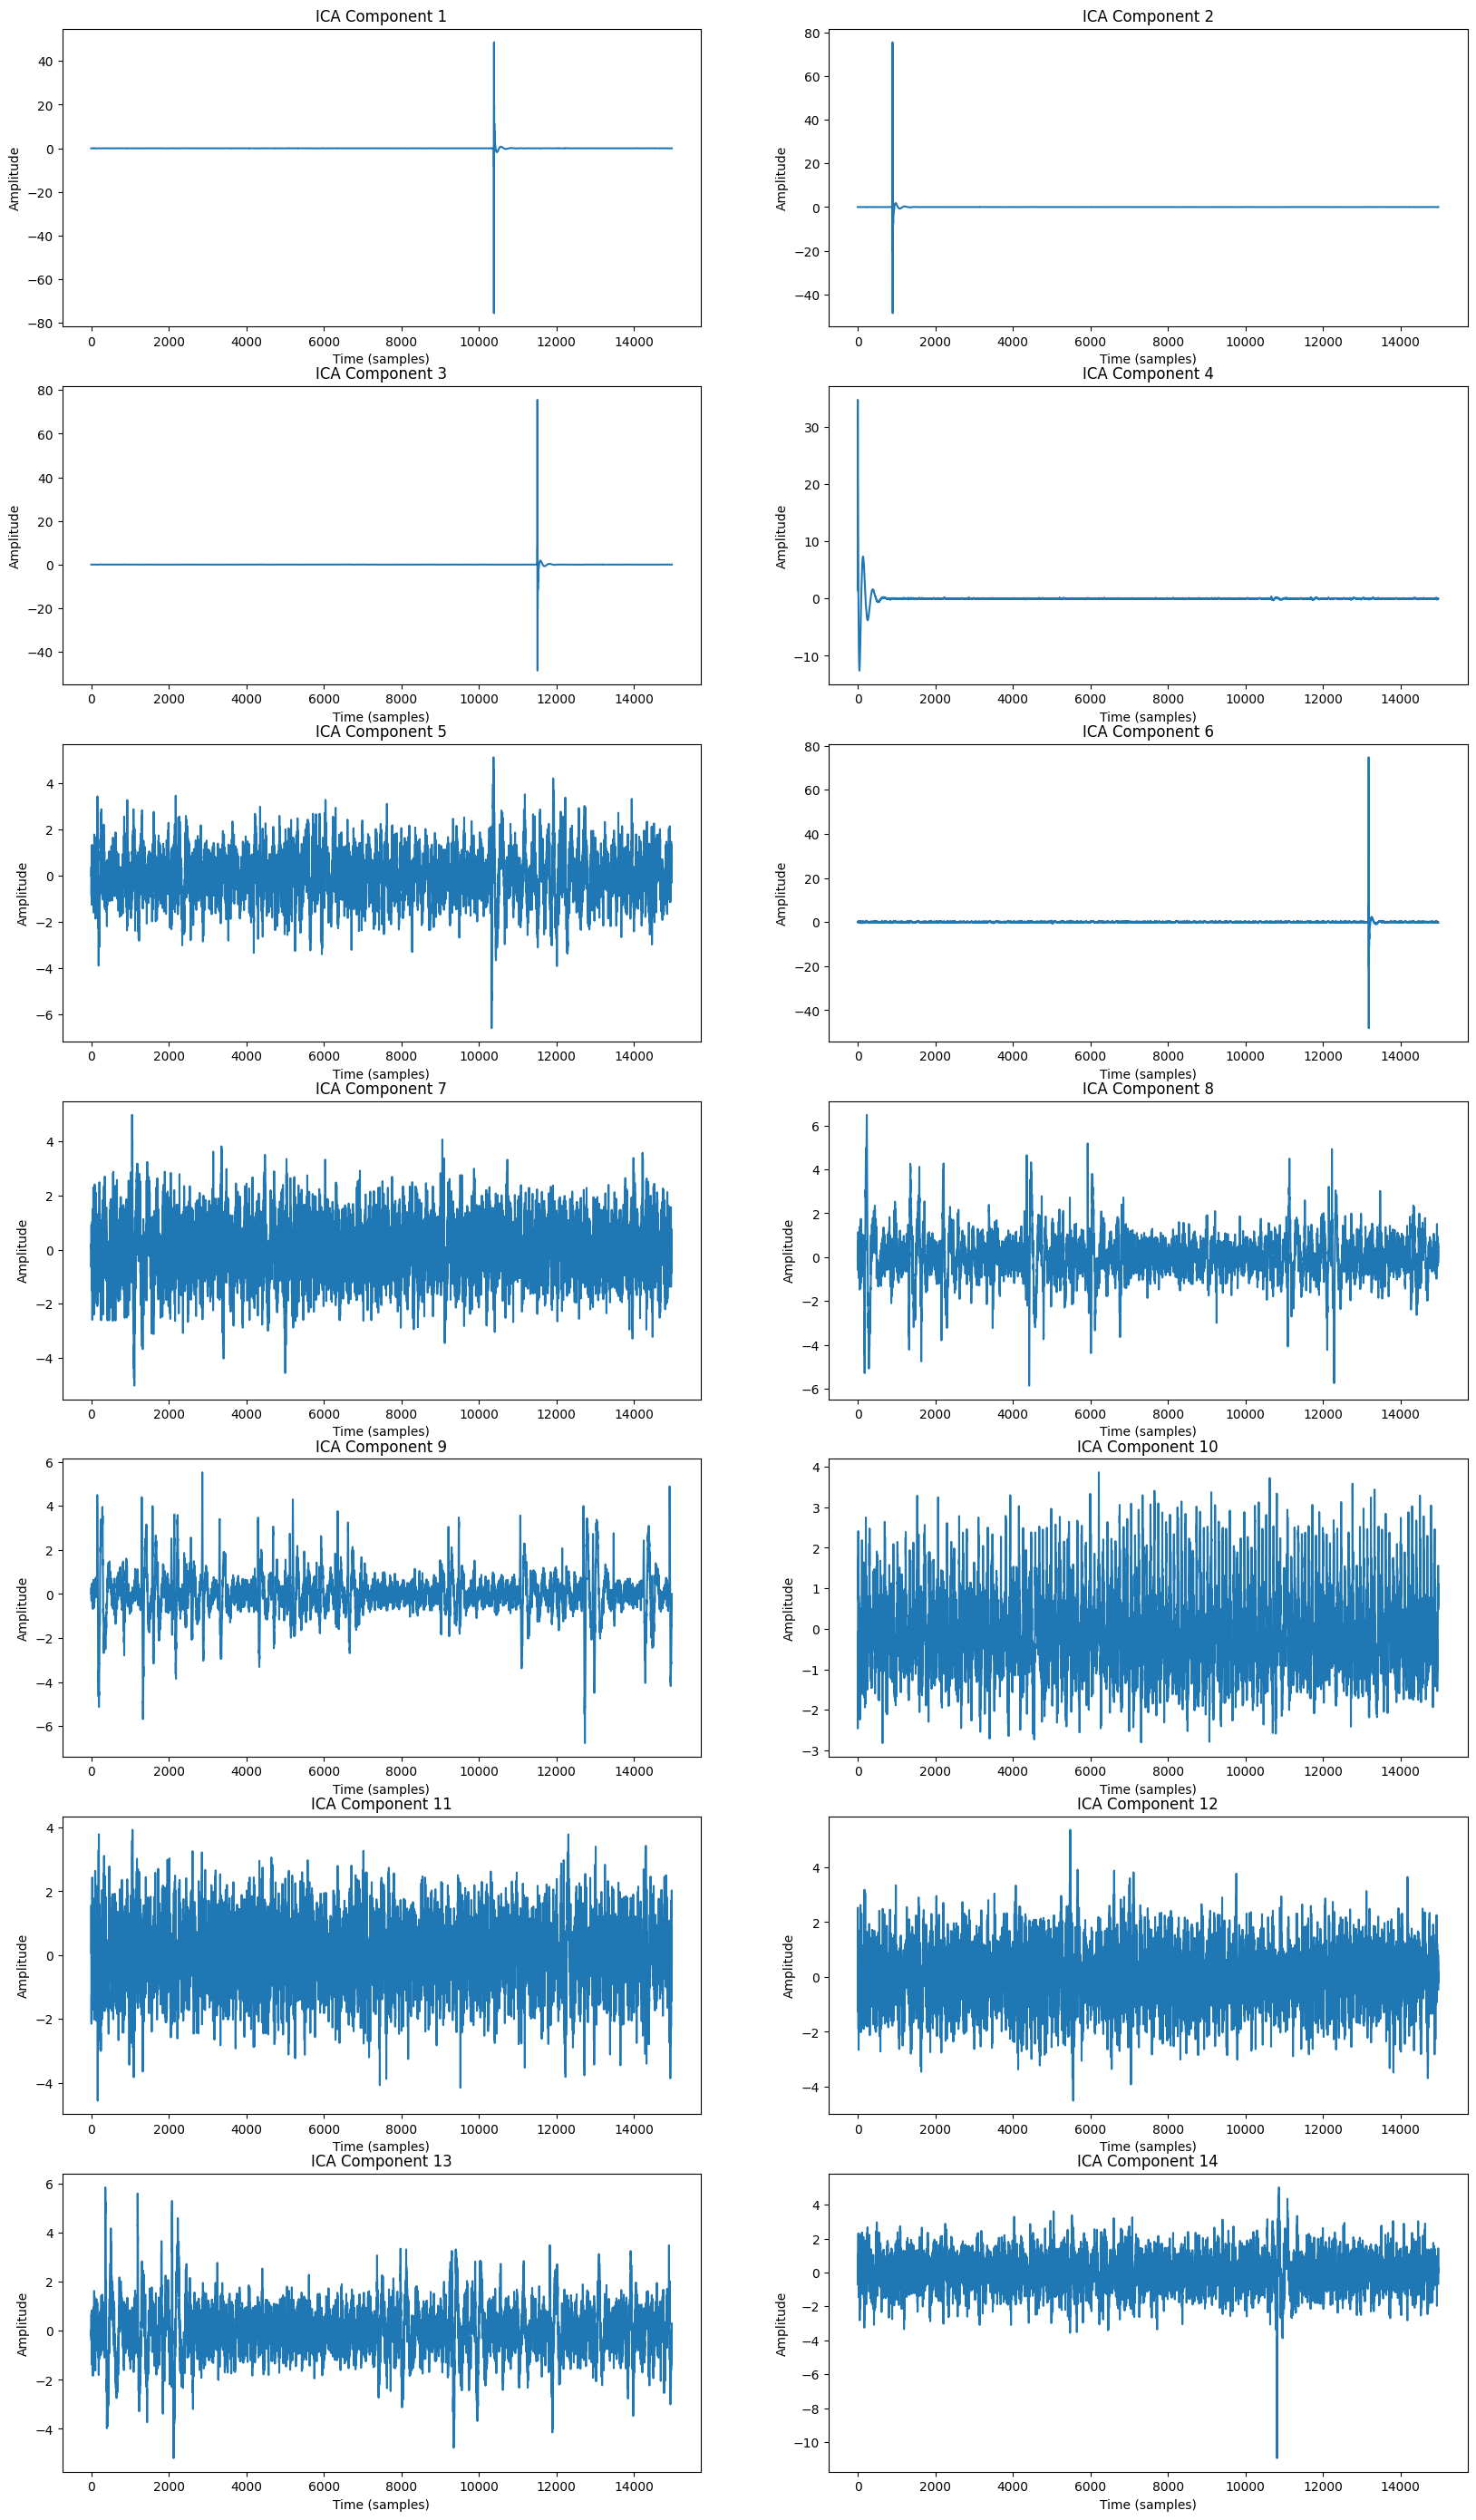

In [101]:
from mne.preprocessing import ICA
import mne


ica = ICA(n_components=14, random_state=0)
raw = mne.io.RawArray(bandpass_filtered_df.T, info=mne.create_info(ch_names=electrodes.tolist(), sfreq=fs, ch_types='eeg'))
ica.fit(raw)
sources = ica.get_sources(raw).get_data().T
ica_df = pd.DataFrame(sources, columns=electrodes)
ica_df['target'] = eeg_df['target']

# plot the ICA components
fig, axs = plt.subplots(7, 2, figsize=(20, 35))
for i, ax in enumerate(axs.flatten()):
    ax.plot(ica_df[electrodes[i]])
    ax.set_title(f'ICA Component {i+1}')
    ax.set_xlabel('Time (samples)')
    ax.set_ylabel('Amplitude')

Creating RawArray with float64 data, n_channels=14, n_times=14980
    Range : 0 ... 14979 =      0.000 ...   117.023 secs
Ready.
Using matplotlib as 2D backend.


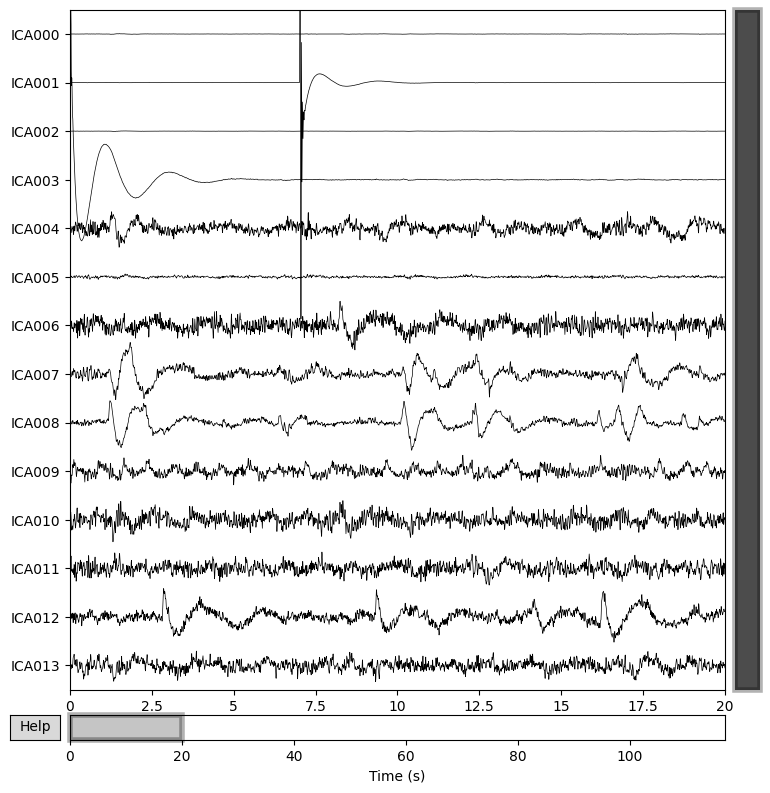

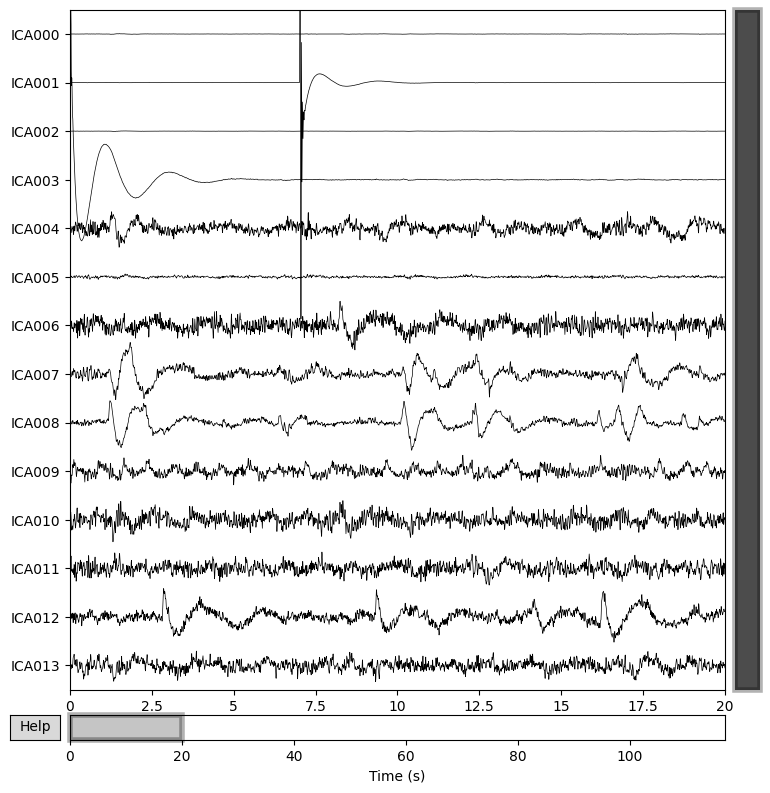

In [103]:
ica.plot_sources(raw)


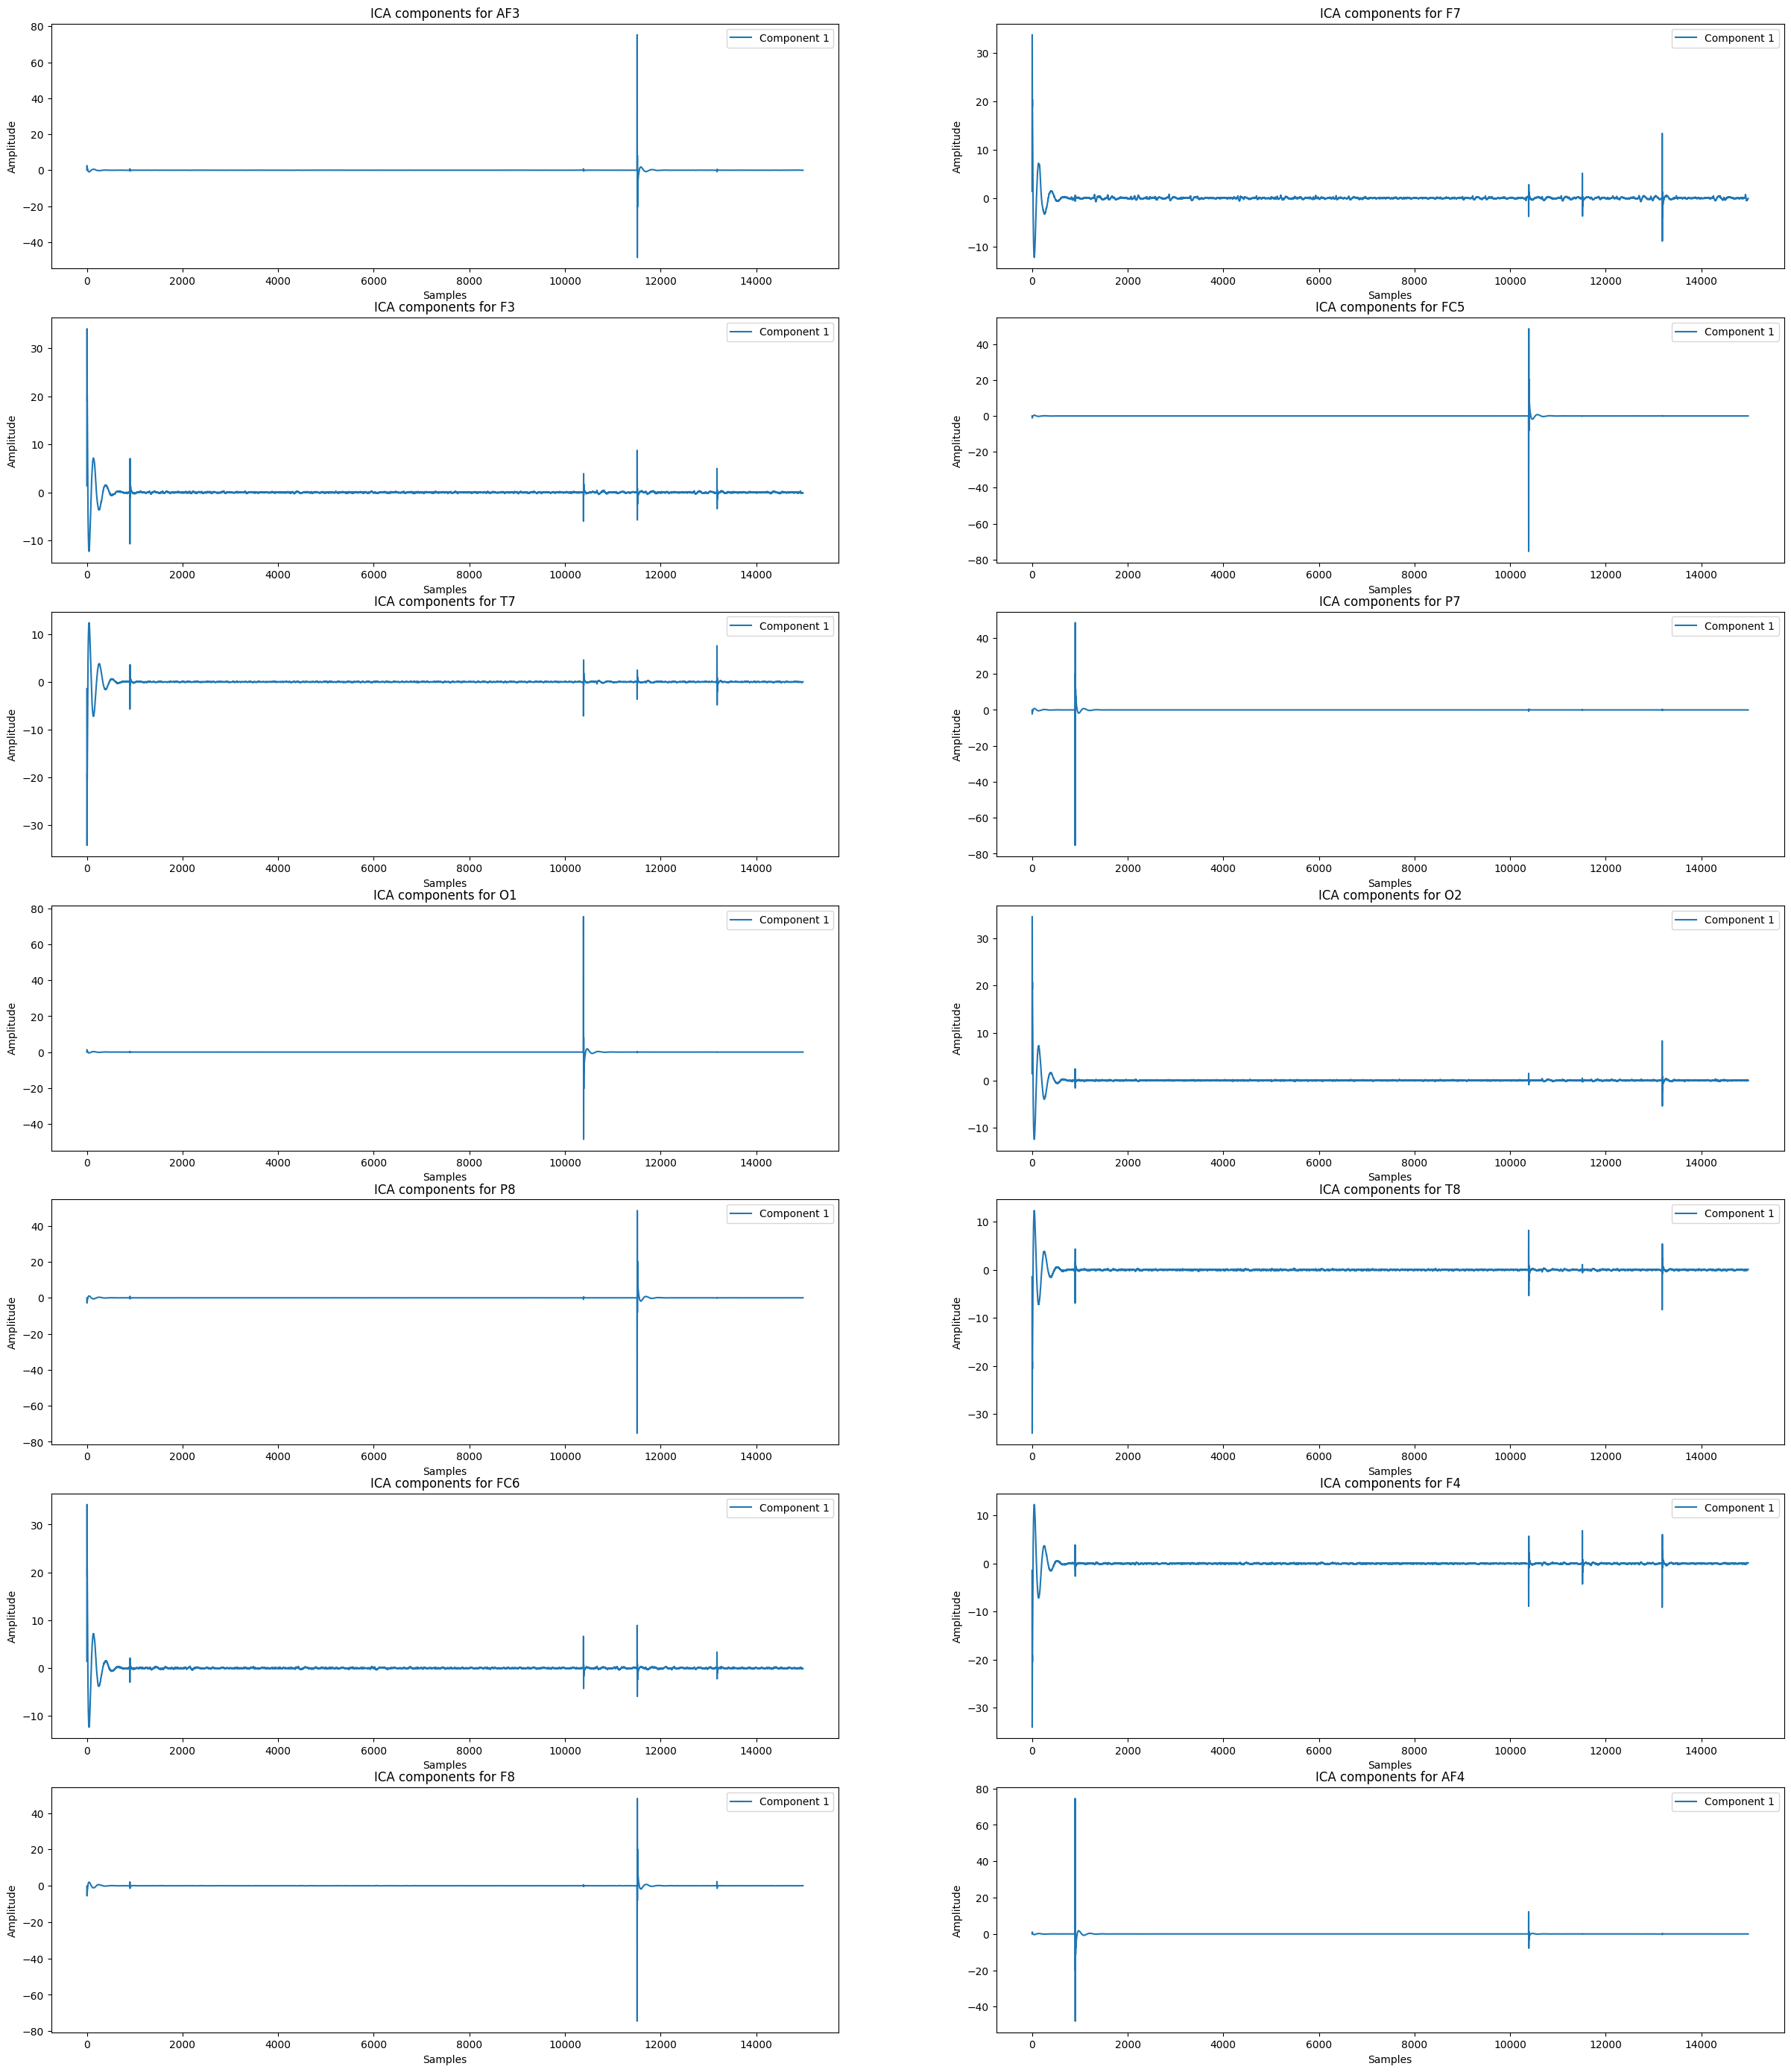

In [104]:
from sklearn.decomposition import FastICA, PCA

columns = electrodes
per_col = 2

fig, axs = plt.subplots(len(columns) // 2, 2, figsize=(30, 35))

for column in columns:
    pca = PCA(n_components=0.95)
    pca.fit(bandpass_filtered_df[column].values.reshape(-1, 1))
    n_components = pca.n_components_
    ica = FastICA(n_components=n_components)
    components = ica.fit_transform(bandpass_filtered_df[column].values.reshape(-1, 1))
    ax = axs[columns.get_loc(column) // per_col, columns.get_loc(column) % per_col]
    ax.plot(components)
    ax.legend([f'Component {i + 1}' for i in range(n_components)])
    ax.set_xlabel('Samples')
    ax.set_ylabel('Amplitude')
    ax.set_title(f'ICA components for {column}')

### Train the models

#### Prepare the data

I will split the data into training and testing sets and normalize the features. I will also extract the subband signals from the EEG signals to use as input features for the models. I will split over time to avoid data leakage. I will extract the subband signals by using the MNE library. 

I will use the following frequency ranges for the subbands:
- Delta: 0.5-4 Hz
- Theta: 4-8 Hz
- Alpha: 8-12 Hz
- Beta: 12-30 Hz
- Gamma: 30-32 Hz


In [ ]:
def extract_subbands(data, fs):
    raw = mne.io.RawArray(data.T, info=mne.create_info(ch_names=electrodes.tolist(), sfreq=fs, ch_types='eeg'))
    raw.filter(0.5, 4, fir_design='firwin')
    delta = raw.get_data().T
    raw.filter(4, 8, fir_design='firwin')
    theta = raw.get_data().T
    raw.filter(8, 12, fir_design='firwin')
    alpha = raw.get_data().T
    raw.filter(12, 30, fir_design='firwin')
    beta = raw.get_data().T
    raw.filter(30, 32, fir_design='firwin')
    gamma = raw.get_data().T
    return delta, theta, alpha, beta, gamma

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import mne

X = bandpass_filtered_df[electrodes]
y = eeg_df['target']

# Split the data into training and testing sets over time to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Normalize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Extract the subband signals
X_train_delta, X_train_theta, X_train_alpha, X_train_beta, X_train_gamma = extract_subbands(X_train, fs)
X_test_delta, X_test_theta, X_test_alpha, X_test_beta, X_test_gamma = extract_subbands(X_test, fs)

# Scale the subband signals
X_train_delta = scaler.transform(pd.DataFrame(X_train_delta, columns=electrodes))
X_train_theta = scaler.transform(pd.DataFrame(X_train_theta, columns=electrodes))
X_train_alpha = scaler.transform(pd.DataFrame(X_train_alpha, columns=electrodes))
X_train_beta = scaler.transform(pd.DataFrame(X_train_beta, columns=electrodes))
X_train_gamma = scaler.transform(pd.DataFrame(X_train_gamma, columns=electrodes))

X_test_delta = scaler.transform(pd.DataFrame(X_test_delta, columns=electrodes))
X_test_theta = scaler.transform(pd.DataFrame(X_test_theta, columns=electrodes))
X_test_alpha = scaler.transform(pd.DataFrame(X_test_alpha, columns=electrodes))
X_test_beta = scaler.transform(pd.DataFrame(X_test_beta, columns=electrodes))
X_test_gamma = scaler.transform(pd.DataFrame(X_test_gamma, columns=electrodes))

# Put all the subband signals into a dataframe with the corresponding electrode names as prefixes
X_train_subbands = pd.DataFrame()
X_test_subbands = pd.DataFrame()
for i, electrode in enumerate(electrodes):
    X_train_subbands[f'{electrode}_delta'] = X_train_delta[:, i]
    X_train_subbands[f'{electrode}_theta'] = X_train_theta[:, i]
    X_train_subbands[f'{electrode}_alpha'] = X_train_alpha[:, i]
    X_train_subbands[f'{electrode}_beta'] = X_train_beta[:, i]
    X_train_subbands[f'{electrode}_gamma'] = X_train_gamma[:, i]
    
    X_test_subbands[f'{electrode}_delta'] = X_test_delta[:, i]
    X_test_subbands[f'{electrode}_theta'] = X_test_theta[:, i]
    X_test_subbands[f'{electrode}_alpha'] = X_test_alpha[:, i]
    X_test_subbands[f'{electrode}_beta'] = X_test_beta[:, i]
    X_test_subbands[f'{electrode}_gamma'] = X_test_gamma[:, i]

X_train_subbands['target'] = y_train.values
X_test_subbands['target'] = y_test.values

Creating RawArray with float64 data, n_channels=14, n_times=11984
    Range : 0 ... 11983 =      0.000 ...    93.617 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 4 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 4.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 5.00 Hz)
- Filter length: 845 samples (6.602 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 8 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuatio

#### Train Logistic Regression model

Accuracy using electrode signals: 0.21
              precision    recall  f1-score   support

           0       0.95      0.13      0.23      2716
           1       0.10      0.93      0.18       280

    accuracy                           0.21      2996
   macro avg       0.52      0.53      0.21      2996
weighted avg       0.87      0.21      0.23      2996

Accuracy using subband signals: 0.24
              precision    recall  f1-score   support

           0       0.93      0.18      0.30      2716
           1       0.10      0.88      0.18       280

    accuracy                           0.24      2996
   macro avg       0.52      0.53      0.24      2996
weighted avg       0.85      0.24      0.28      2996



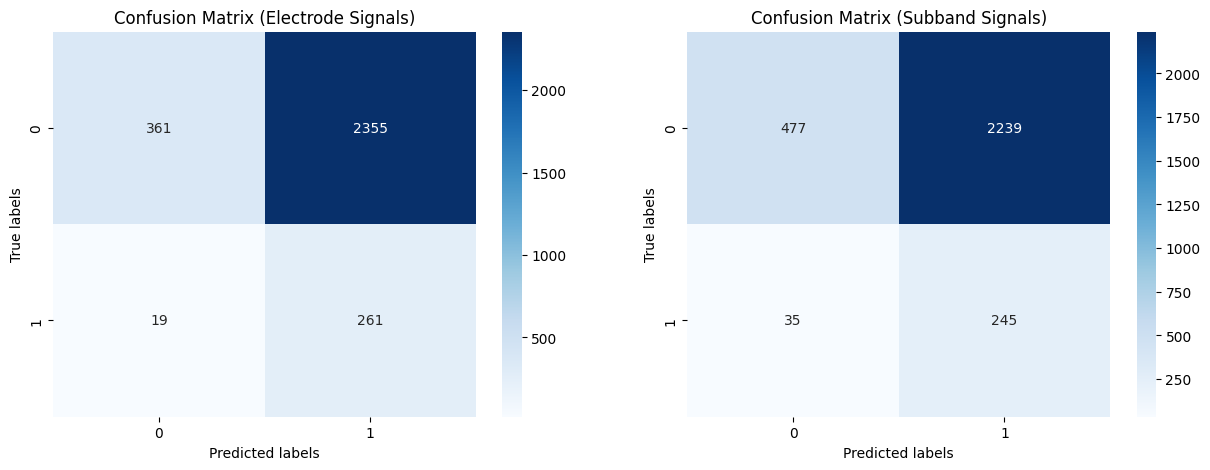

In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train the Logistic Regression model using the electrode signals
lr_electrode = LogisticRegression(max_iter=1000)
lr_electrode.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_electrode = lr_electrode.predict(X_test_scaled)
accuracy_electrode = accuracy_score(y_test, y_pred_electrode)
print(f'Accuracy using electrode signals: {accuracy_electrode:.2f}')
print(classification_report(y_test, y_pred_electrode))

# Train the Logistic Regression model using the subband signals
lr_subbands = LogisticRegression(max_iter=1000)
lr_subbands.fit(X_train_subbands.drop(columns='target'), y_train)

# Make predictions on the test set
y_pred_subbands = lr_subbands.predict(X_test_subbands.drop(columns='target'))
accuracy_subbands = accuracy_score(y_test, y_pred_subbands)
print(f'Accuracy using subband signals: {accuracy_subbands:.2f}')
print(classification_report(y_test, y_pred_subbands))

# Plot the confusion matrices
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
conf_matrix_electrode = confusion_matrix(y_test, y_pred_electrode)
sns.heatmap(conf_matrix_electrode, annot=True, cmap='Blues', fmt='g', ax=axs[0])
axs[0].set_xlabel('Predicted labels')
axs[0].set_ylabel('True labels')
axs[0].set_title('Confusion Matrix (Electrode Signals)')
conf_matrix_subbands = confusion_matrix(y_test, y_pred_subbands)
sns.heatmap(conf_matrix_subbands, annot=True, cmap='Blues', fmt='g', ax=axs[1])
axs[1].set_xlabel('Predicted labels')
axs[1].set_ylabel('True labels')
axs[1].set_title('Confusion Matrix (Subband Signals)')
plt.show()

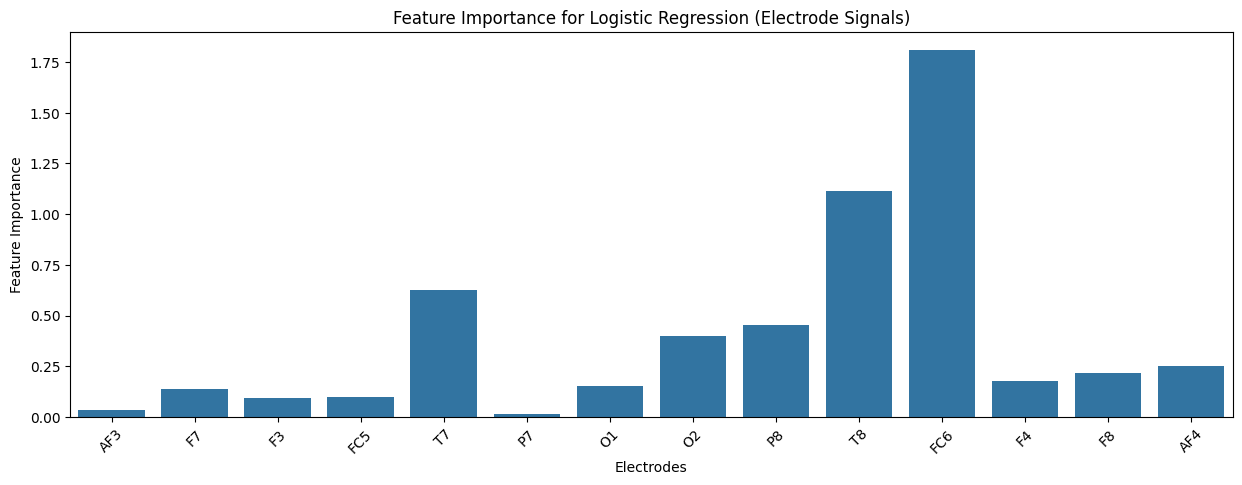

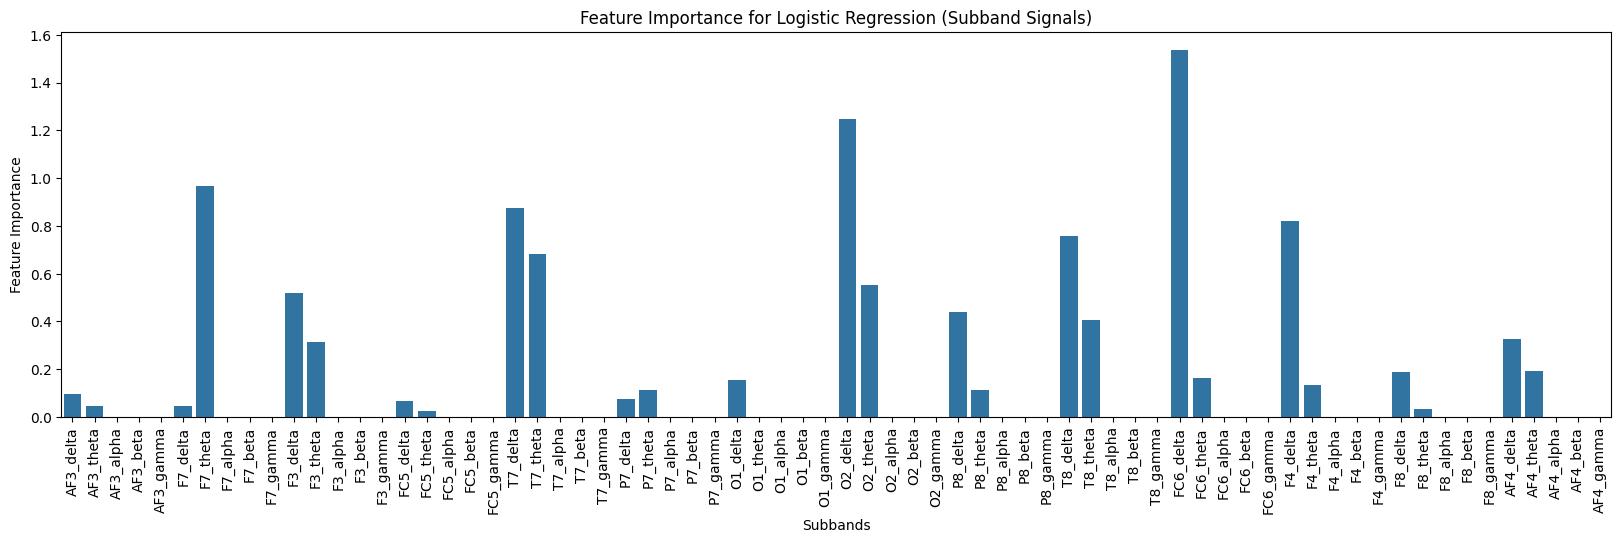

In [85]:
# Plot the feature importance for the Logistic Regression model using the electrode signals
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
feature_importance_electrode = np.abs(lr_electrode.coef_[0])
sns.barplot(x=electrodes, y=feature_importance_electrode, ax=ax)
ax.set_xlabel('Electrodes')
ax.set_ylabel('Feature Importance')
ax.set_title('Feature Importance for Logistic Regression (Electrode Signals)')
plt.xticks(rotation=45)
plt.show()

# Plot the feature importance for the Logistic Regression model using the subband signals 
fig, ax = plt.subplots(1, 1, figsize=(20, 5))
feature_importance_subbands = np.abs(lr_subbands.coef_[0])
sns.barplot(x=X_train_subbands.drop(columns='target').columns, y=feature_importance_subbands, ax=ax)
ax.set_xlabel('Subbands')
ax.set_ylabel('Feature Importance')
ax.set_title('Feature Importance for Logistic Regression (Subband Signals)')
plt.xticks(rotation=90)
plt.show()

#### Train EBM model

Accuracy using electrode signals: 0.37
Accuracy using subband signals: 0.33


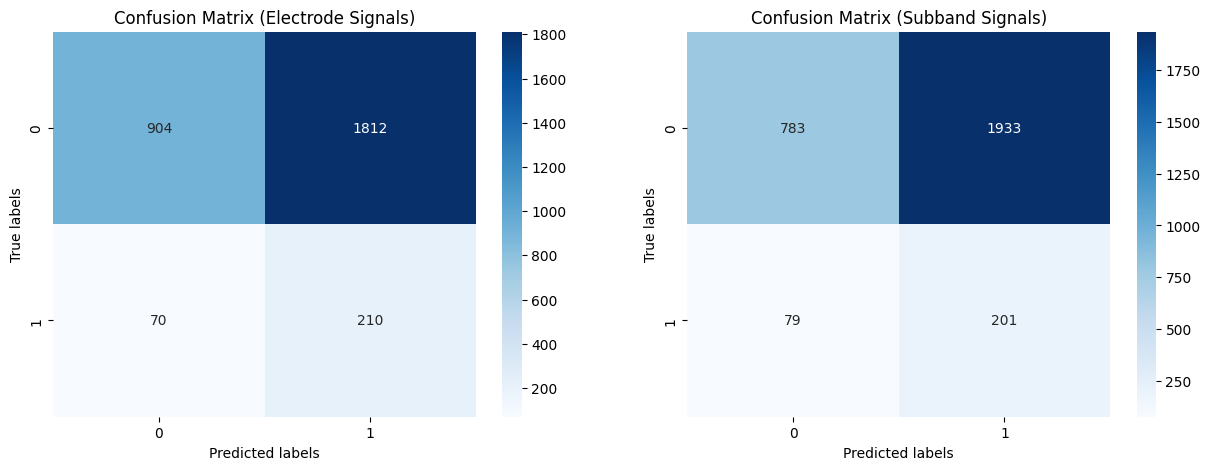

In [82]:
from interpret.glassbox import ExplainableBoostingClassifier

# Train the EBM model using the electrode signals
ebm_electrode = ExplainableBoostingClassifier()
ebm_electrode.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_ebm_electrode = ebm_electrode.predict(X_test_scaled)
accuracy_ebm_electrode = accuracy_score(y_test, y_pred_ebm_electrode)
print(f'Accuracy using electrode signals: {accuracy_ebm_electrode:.2f}')

# Train the EBM model using the subband signals
ebm_subbands = ExplainableBoostingClassifier()
ebm_subbands.fit(X_train_subbands.drop(columns='target'), y_train)

# Make predictions on the test set
y_pred_ebm_subbands = ebm_subbands.predict(X_test_subbands.drop(columns='target'))
accuracy_ebm_subbands = accuracy_score(y_test, y_pred_ebm_subbands)
print(f'Accuracy using subband signals: {accuracy_ebm_subbands:.2f}')

# Plot the confusion matrices
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
conf_matrix_ebm_electrode = confusion_matrix(y_test, y_pred_ebm_electrode)
sns.heatmap(conf_matrix_ebm_electrode, annot=True, cmap='Blues', fmt='g', ax=axs[0])
axs[0].set_xlabel('Predicted labels')
axs[0].set_ylabel('True labels')
axs[0].set_title('Confusion Matrix (Electrode Signals)')
conf_matrix_ebm_subbands = confusion_matrix(y_test, y_pred_ebm_subbands)
sns.heatmap(conf_matrix_ebm_subbands, annot=True, cmap='Blues', fmt='g', ax=axs[1])
axs[1].set_xlabel('Predicted labels')
axs[1].set_ylabel('True labels')
axs[1].set_title('Confusion Matrix (Subband Signals)')
plt.show()

#### Train XGBoost model

/home/paquetlab/workspace/EEG_Interface/.venv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [20:43:42] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy using electrode signals: 0.38


/home/paquetlab/workspace/EEG_Interface/.venv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [20:43:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy using subband signals: 0.34


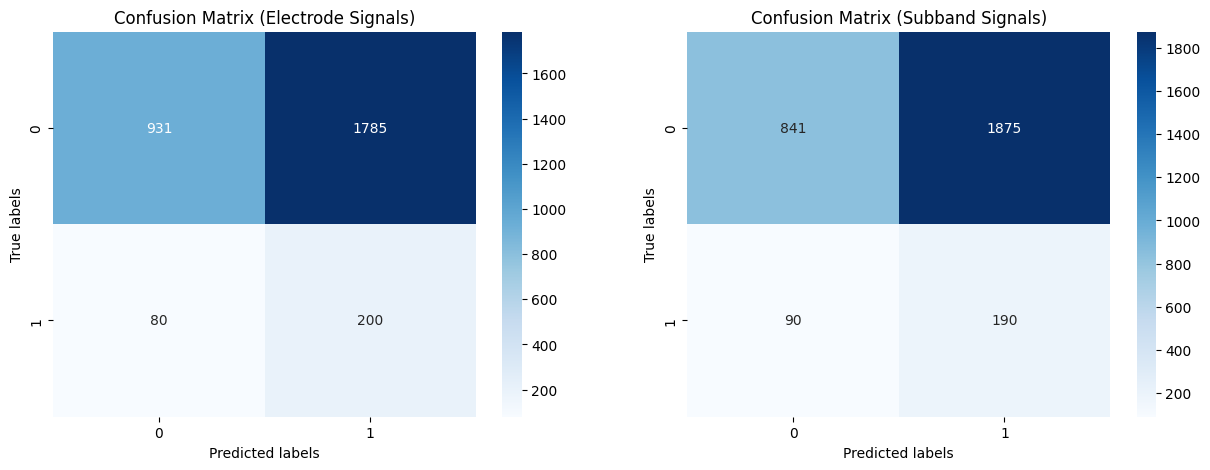

In [86]:
from xgboost import XGBClassifier

# Train the XGBoost model using the electrode signals
xgb_electrode = XGBClassifier(use_label_encoder=False)
xgb_electrode.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_xgb_electrode = xgb_electrode.predict(X_test_scaled)
accuracy_xgb_electrode = accuracy_score(y_test, y_pred_xgb_electrode)
print(f'Accuracy using electrode signals: {accuracy_xgb_electrode:.2f}')

# Train the XGBoost model using the subband signals
xgb_subbands = XGBClassifier(use_label_encoder=False)
xgb_subbands.fit(X_train_subbands.drop(columns='target'), y_train)

# Make predictions on the test set
y_pred_xgb_subbands = xgb_subbands.predict(X_test_subbands.drop(columns='target'))
accuracy_xgb_subbands = accuracy_score(y_test, y_pred_xgb_subbands)
print(f'Accuracy using subband signals: {accuracy_xgb_subbands:.2f}')

# Plot the confusion matrices
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
conf_matrix_xgb_electrode = confusion_matrix(y_test, y_pred_xgb_electrode)
sns.heatmap(conf_matrix_xgb_electrode, annot=True, cmap='Blues', fmt='g', ax=axs[0])
axs[0].set_xlabel('Predicted labels')
axs[0].set_ylabel('True labels')
axs[0].set_title('Confusion Matrix (Electrode Signals)')
conf_matrix_xgb_subbands = confusion_matrix(y_test, y_pred_xgb_subbands)
sns.heatmap(conf_matrix_xgb_subbands, annot=True, cmap='Blues', fmt='g', ax=axs[1])
axs[1].set_xlabel('Predicted labels')
axs[1].set_ylabel('True labels')
axs[1].set_title('Confusion Matrix (Subband Signals)')
plt.show()

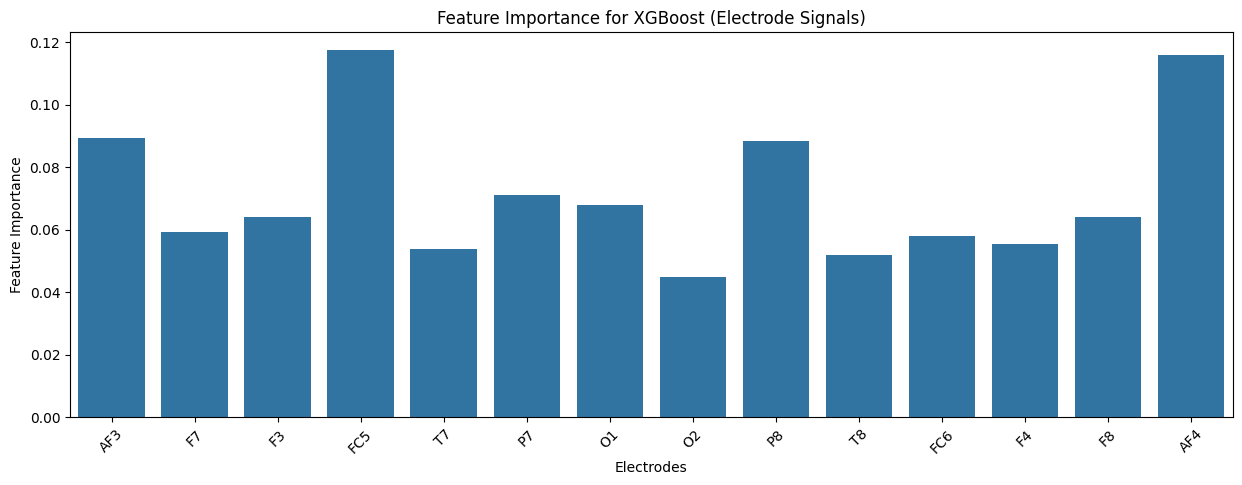

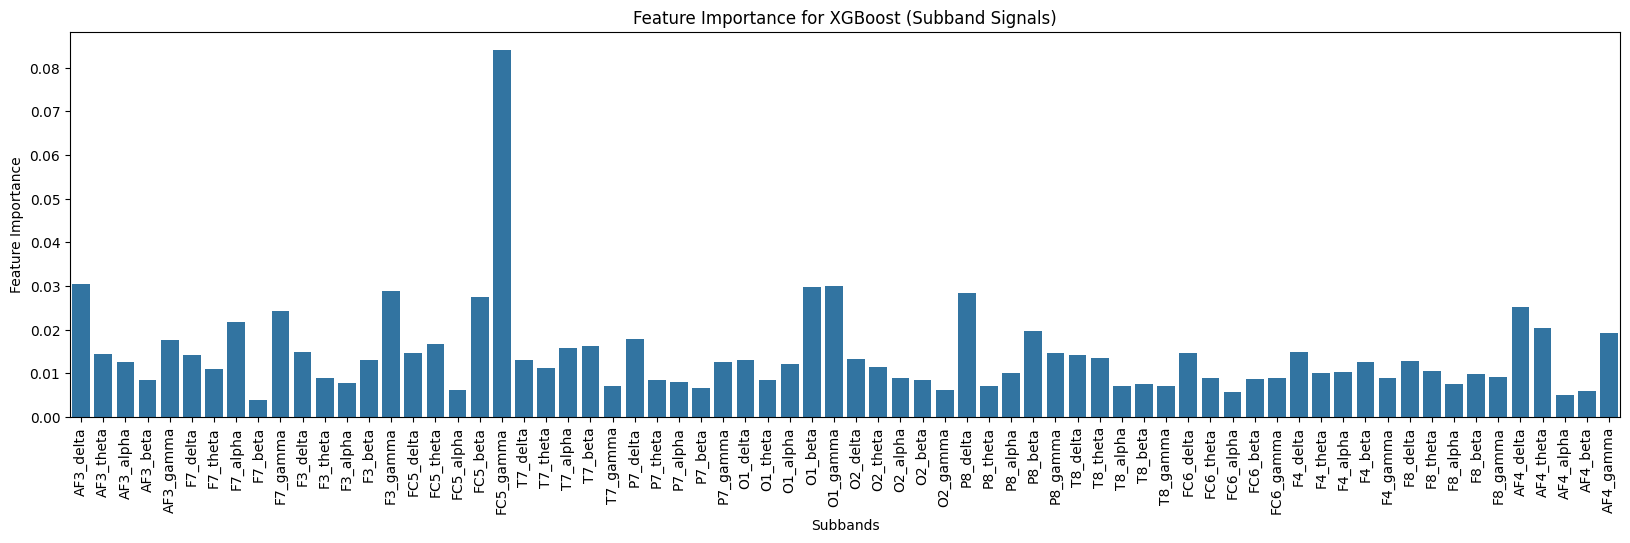

In [87]:
# Plot the feature importance for the XGBoost model using the electrode signals
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
feature_importance_xgb_electrode = xgb_electrode.feature_importances_
sns.barplot(x=electrodes, y=feature_importance_xgb_electrode, ax=ax)
ax.set_xlabel('Electrodes')
ax.set_ylabel('Feature Importance')
ax.set_title('Feature Importance for XGBoost (Electrode Signals)')
plt.xticks(rotation=45)
plt.show()

# Plot the feature importance for the XGBoost model using the subband signals
fig, ax = plt.subplots(1, 1, figsize=(20, 5))
feature_importance_xgb_subbands = xgb_subbands.feature_importances_
sns.barplot(x=X_train_subbands.drop(columns='target').columns, y=feature_importance_xgb_subbands, ax=ax)
ax.set_xlabel('Subbands')
ax.set_ylabel('Feature Importance')
ax.set_title('Feature Importance for XGBoost (Subband Signals)')
plt.xticks(rotation=90)
plt.show()

#### Train XGBoost model with suffle data

/home/paquetlab/workspace/EEG_Interface/.venv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [20:51:57] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy using electrode signals (shuffled data): 0.74


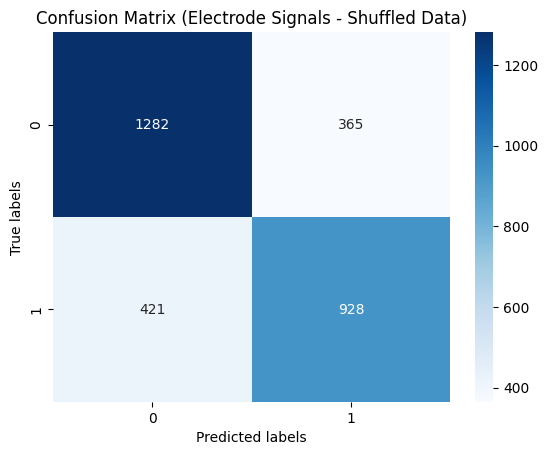

In [89]:
# Split the data into training and testing sets
X_train_suffle, X_test_suffle, y_train_suffle, y_test_suffle = train_test_split(X, y, test_size=0.2, shuffle=True)

# Normalize the features
scaler_suffle = StandardScaler()
X_train_scaled_suffle = scaler_suffle.fit_transform(X_train_suffle)
X_test_scaled_suffle = scaler_suffle.transform(X_test_suffle)

# Train the XGBoost model using the electrode signals
xgb_electrode_suffle = XGBClassifier(use_label_encoder=False)
xgb_electrode_suffle.fit(X_train_scaled_suffle, y_train_suffle)

# Make predictions on the test set
y_pred_xgb_electrode_suffle = xgb_electrode_suffle.predict(X_test_scaled_suffle)
accuracy_xgb_electrode_suffle = accuracy_score(y_test_suffle, y_pred_xgb_electrode_suffle)
print(f'Accuracy using electrode signals (shuffled data): {accuracy_xgb_electrode_suffle:.2f}')

# Plot the confusion matrix
conf_matrix_xgb_electrode_suffle = confusion_matrix(y_test_suffle, y_pred_xgb_electrode_suffle)
sns.heatmap(conf_matrix_xgb_electrode_suffle, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix (Electrode Signals - Shuffled Data)')
plt.show()

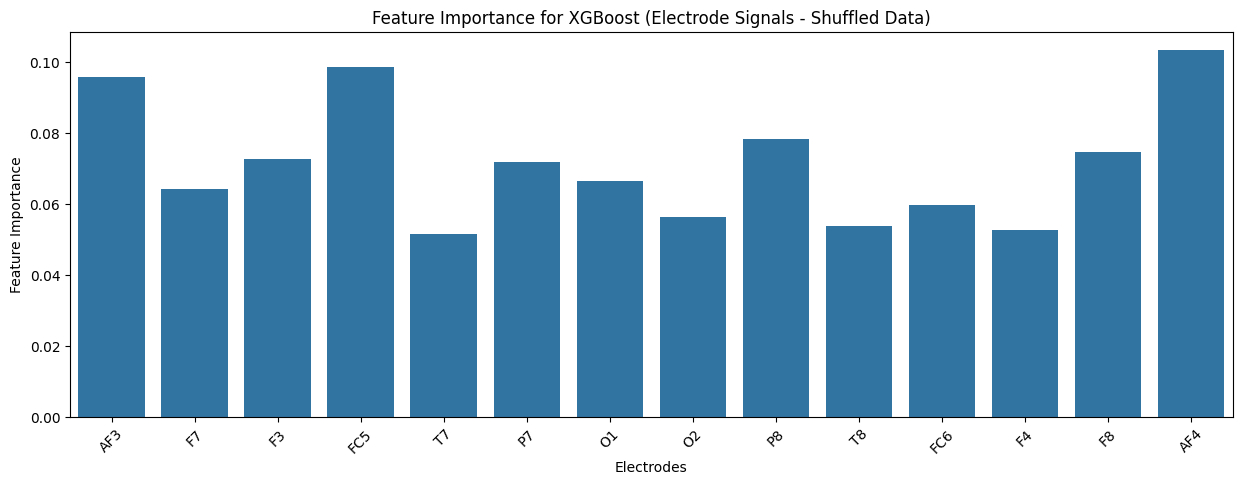

In [90]:
# Plot the feature importance for the XGBoost model using the electrode signals
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
feature_importance_xgb_electrode_suffle = xgb_electrode_suffle.feature_importances_
sns.barplot(x=electrodes, y=feature_importance_xgb_electrode_suffle, ax=ax)
ax.set_xlabel('Electrodes')
ax.set_ylabel('Feature Importance')
ax.set_title('Feature Importance for XGBoost (Electrode Signals - Shuffled Data)')
plt.xticks(rotation=45)
plt.show()

### Analyse the prediction

#### Plot the relative bandpower for each subband per electrode and per class

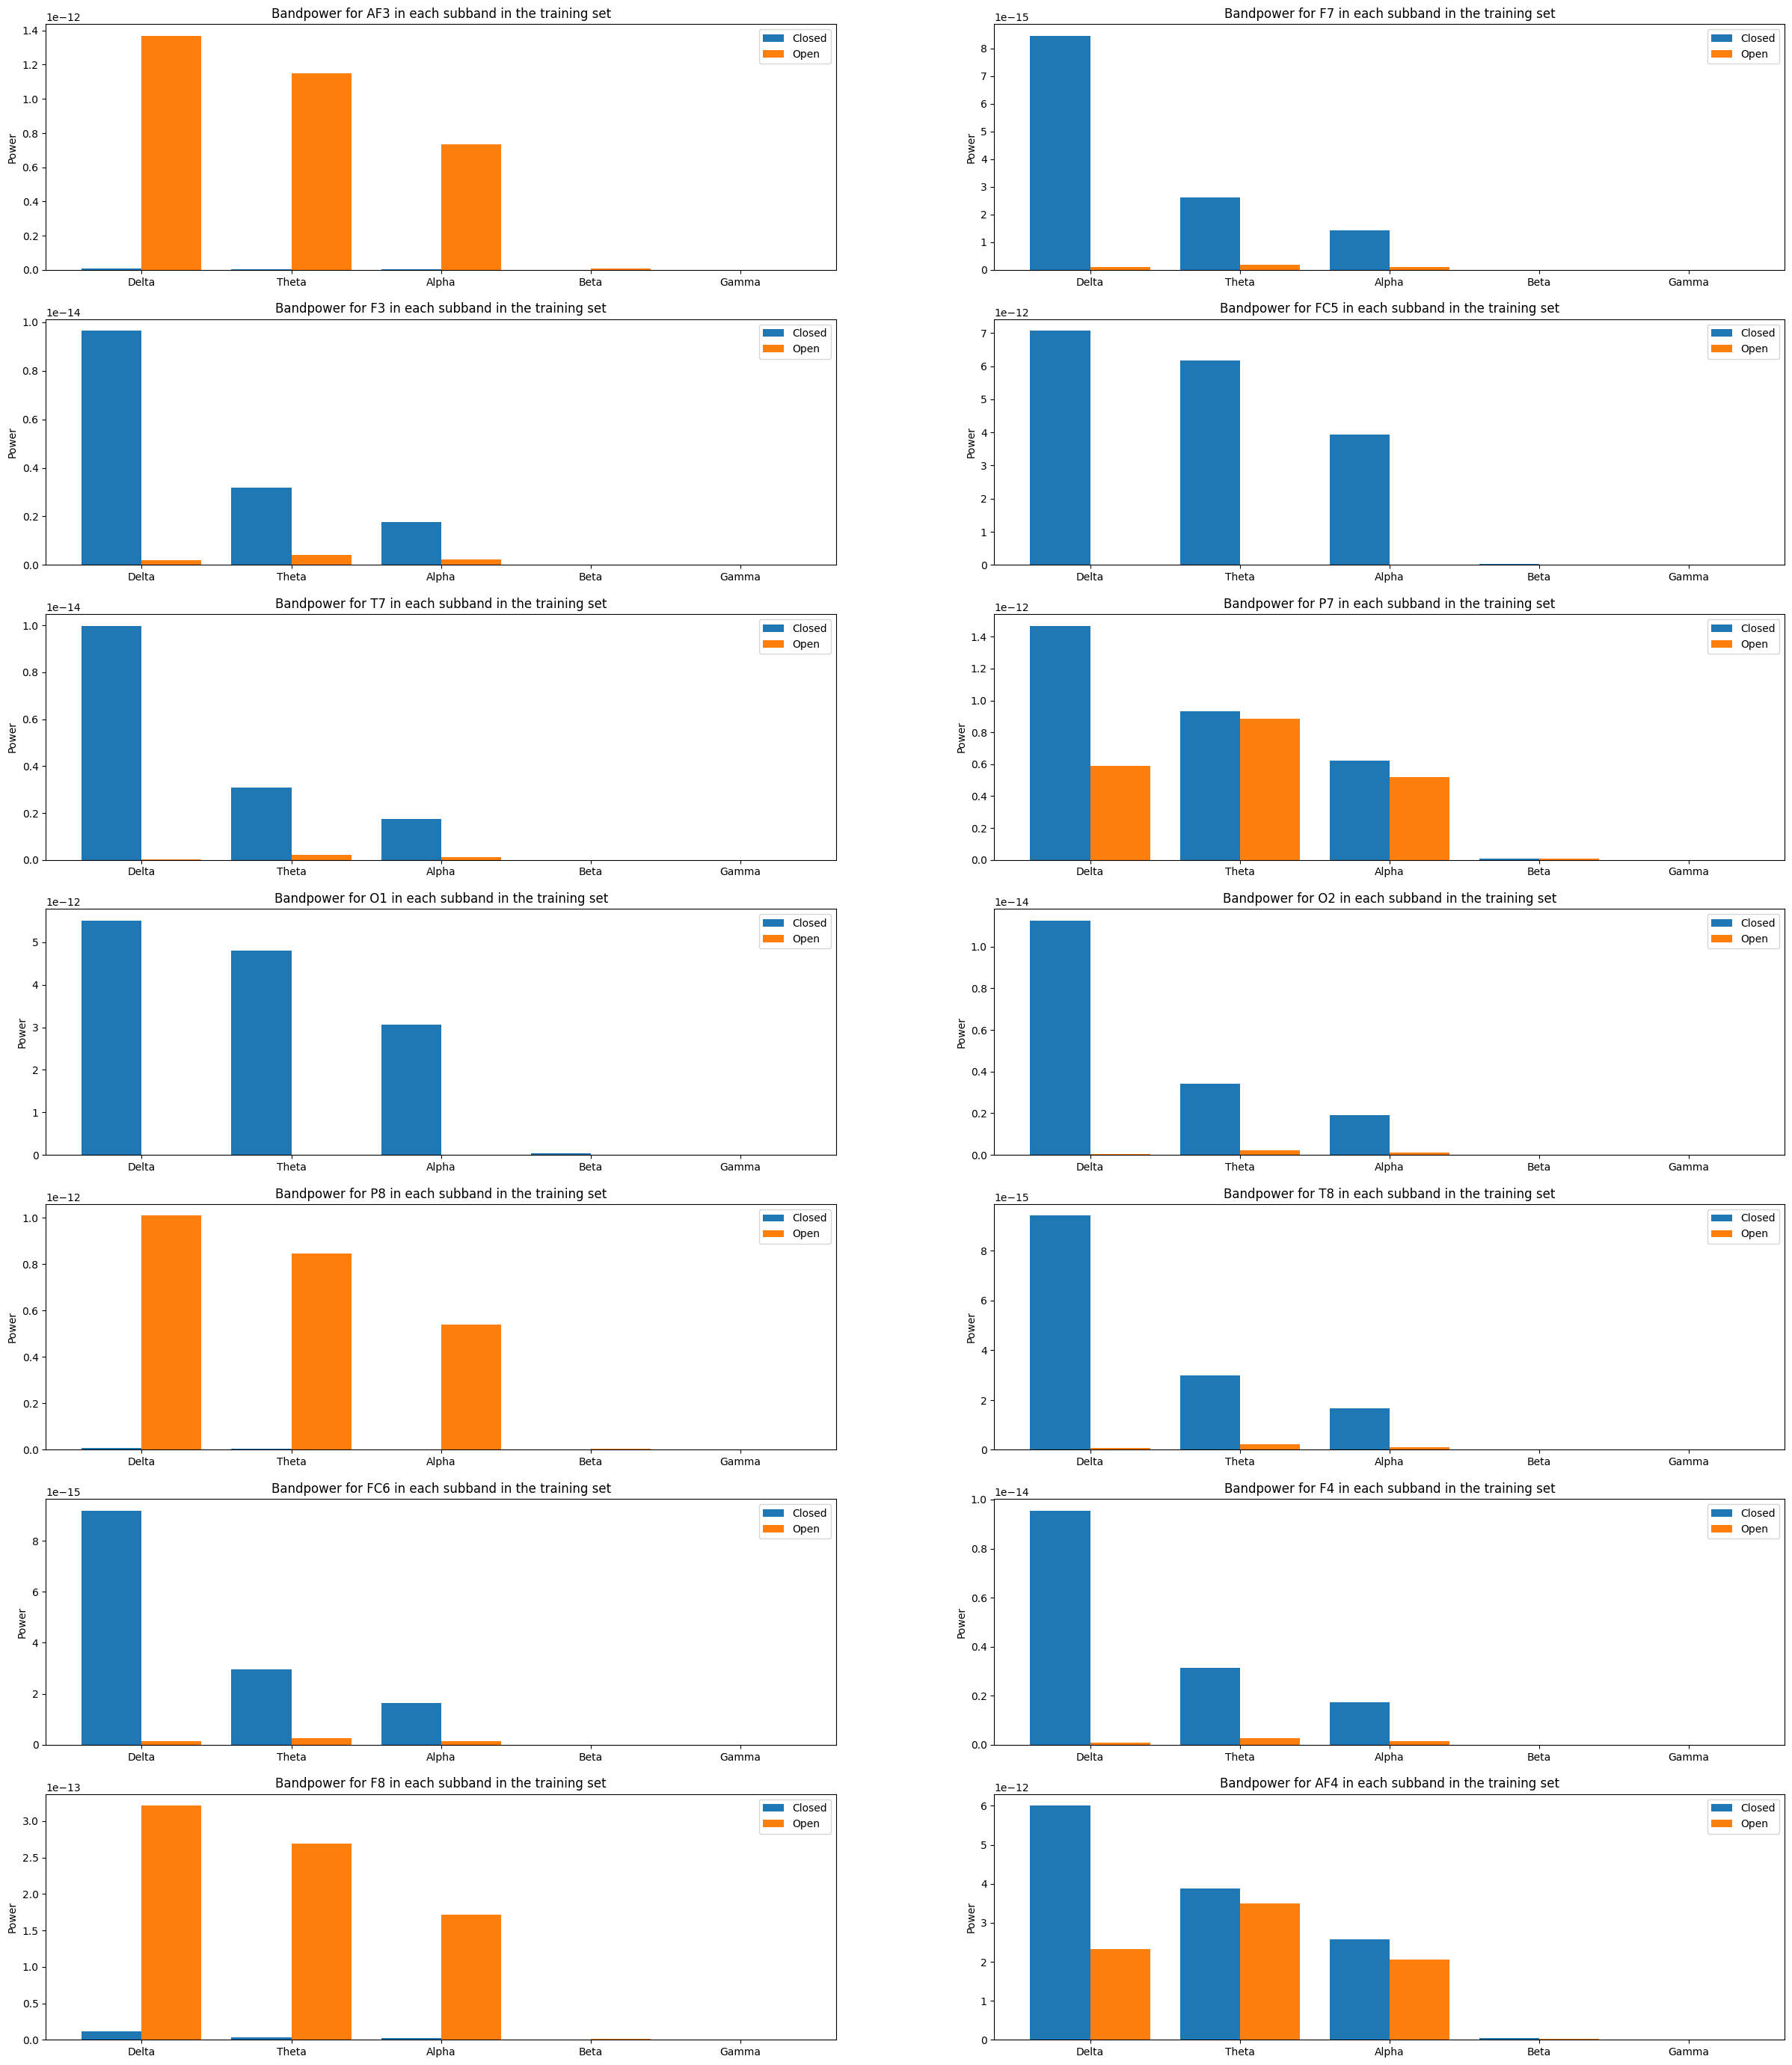

In [95]:
from scipy.signal import welch

columns = X_train.columns
per_col = 2

fig, axs = plt.subplots(len(columns)//2, 2, figsize=(30, 35))

for column in columns:
    bandpower = np.zeros((5, 2))
    for t in range(2):
        f, Pxx = welch(X_train[column][y_train == t], fs=fs, window='hamming')
        for i, (low, high) in enumerate([(0, 4), (4, 8), (8, 12), (12, 30), (30, 32)]):
            bandpower[i, t] = np.mean(Pxx[(f >= low) & (f < high)])
    ax = axs[columns.get_loc(column) // per_col, columns.get_loc(column) % per_col]
    ax.bar(np.arange(5)-0.2, bandpower[:, 0], width=0.4, label='Closed')
    ax.bar(np.arange(5)+0.2, bandpower[:, 1], width=0.4, label='Open')
    ax.set_xticks(np.arange(5))
    ax.set_xticklabels(['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma'])
    ax.set_ylabel('Power')
    ax.set_title(f'Bandpower for {column} in each subband in the training set')
    ax.legend()

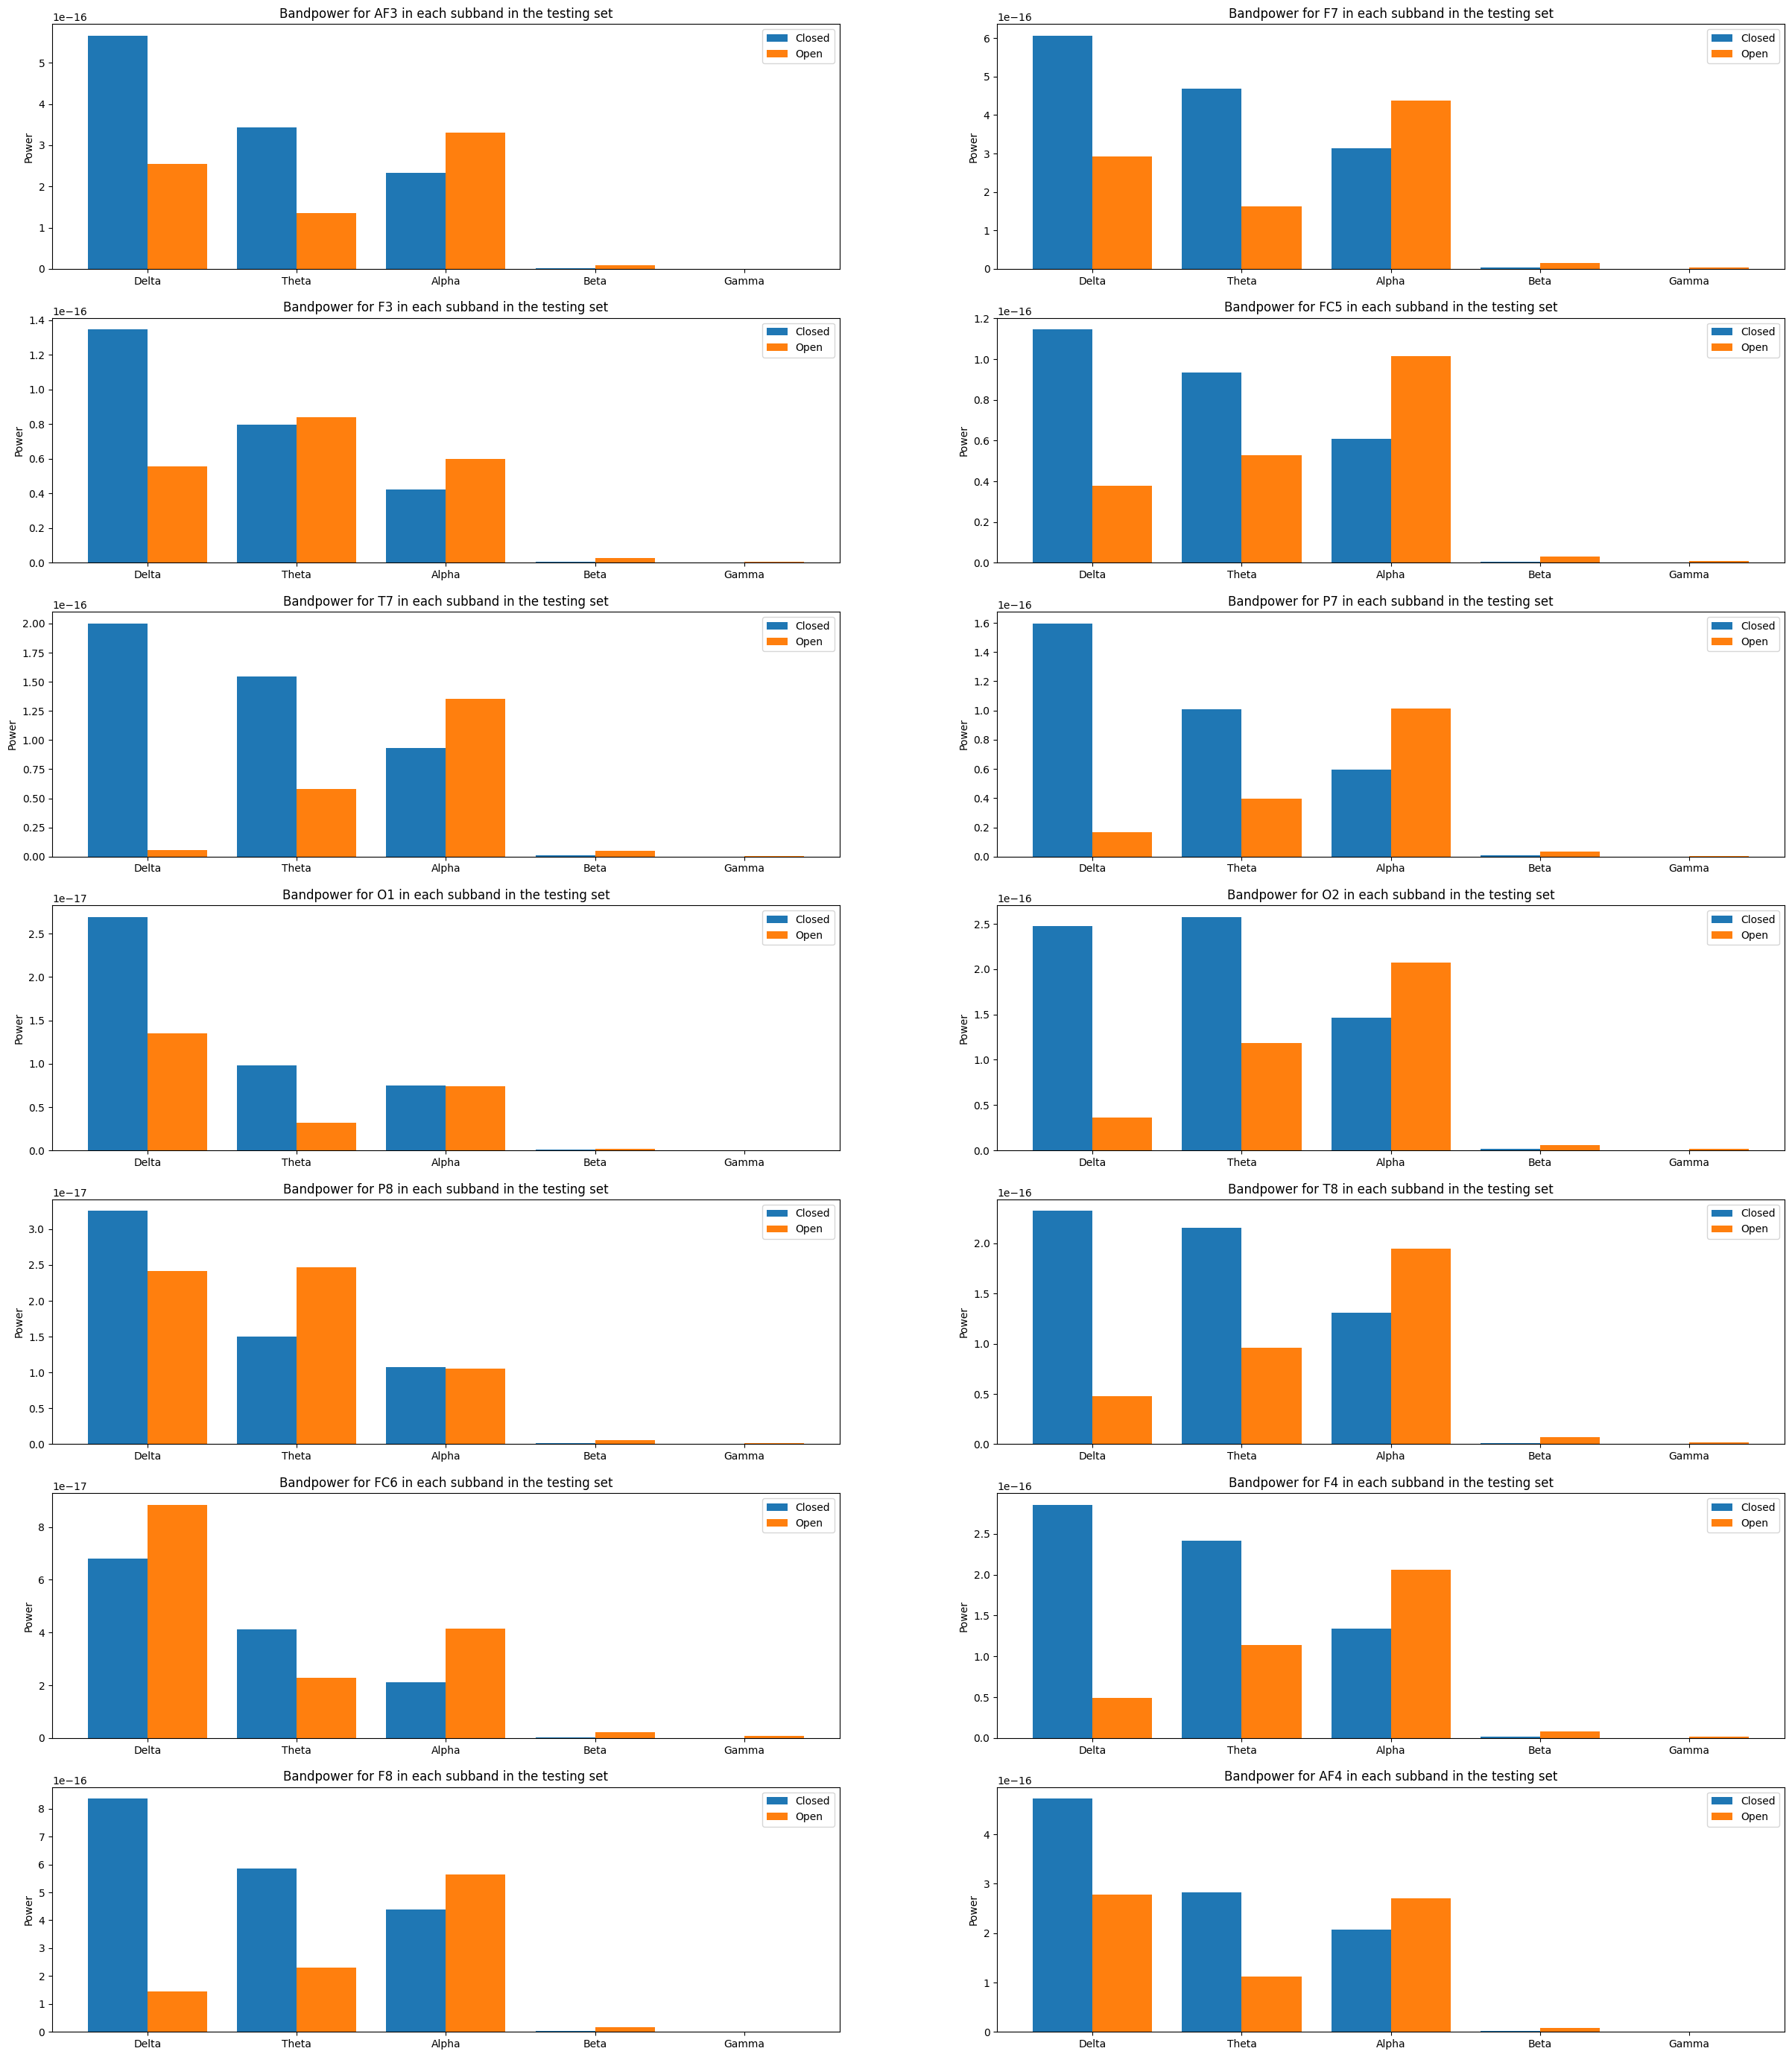

In [96]:
from scipy.signal import welch

columns = X_test.columns
per_col = 2

fig, axs = plt.subplots(len(columns)//2, 2, figsize=(30, 35))

for column in columns:
    bandpower = np.zeros((5, 2))
    for t in range(2):
        f, Pxx = welch(X_test[column][y_test == t], fs=fs, window='hamming')
        for i, (low, high) in enumerate([(0, 4), (4, 8), (8, 12), (12, 30), (30, 32)]):
            bandpower[i, t] = np.mean(Pxx[(f >= low) & (f < high)])
    ax = axs[columns.get_loc(column) // per_col, columns.get_loc(column) % per_col]
    ax.bar(np.arange(5)-0.2, bandpower[:, 0], width=0.4, label='Closed')
    ax.bar(np.arange(5)+0.2, bandpower[:, 1], width=0.4, label='Open')
    ax.set_xticks(np.arange(5))
    ax.set_xticklabels(['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma'])
    ax.set_ylabel('Power')
    ax.set_title(f'Bandpower for {column} in each subband in the testing set')
    ax.legend()

#### Explain model prediction using SHAP

SHAP (SHapley Additive exPlanations) is a game theoretic approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations using the classic Shapley values from game theory and their related extensions. 

##### Logistic Regression model

In [106]:
!pip install numpy==2.0

/bin/bash: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
/bin/bash: line 1: pip: command not found


In [117]:
import numpy as np
import shap

# Initialize the SHAP explainer
explainer = shap.Explainer(lr_electrode, X_train_scaled)

# Calculate SHAP values
shap_values = explainer(X_test_scaled)

# Plot the SHAP summary plot
shap.summary_plot(shap_values, X_test_scaled, feature_names=electrodes)

ImportError: Numba needs NumPy 2.0 or less. Got NumPy 2.1.